# Part 2: The Overlay Strategy
## AI Bubble (2023-2025) vs Dot-com Bubble (1999-2001)



This notebook performs **Overlay Analysis** by aligning stock price data from two distinct market eras to compare bubble behavior and market dynamics.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Theme & Style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color Palette 
C_DOTCOM = '#E74C3C'   # Red-ish for Dot-com era
C_AI     = '#2E86C1'   # Blue-ish for AI era
C_DOTCOM2 = '#F39C12'  # Secondary Dot-com
C_AI2     = '#1ABC9C'  # Secondary AI

print("Setup complete")

Setup complete


In [2]:
# Load Data 
ai_df = pd.read_csv('ai_price.csv', parse_dates=['Date'], index_col='Date')
dc_df = pd.read_csv('dotcom_price.csv', parse_dates=['Date'], index_col='Date')

print(f"AI Data   : {ai_df.index.min().date()} to {ai_df.index.max().date()}  ({len(ai_df)} trading days)")
print(f"Dot-com   : {dc_df.index.min().date()} to {dc_df.index.max().date()}  ({len(dc_df)} trading days)")
print()
print("AI columns      :", list(ai_df.columns))
print("Dot-com columns :", list(dc_df.columns))

AI Data   : 2023-01-03 to 2025-12-31  (752 trading days)
Dot-com   : 1999-01-04 to 2001-12-31  (752 trading days)

AI columns      : ['AMD', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'ORCL', 'PLTR', '^IXIC']
Dot-com columns : ['AMZN', 'CSCO', 'INTC', 'MSFT', 'MSTR', 'ORCL', 'QCOM', '^IXIC']


In [3]:
# Helper Functions
def normalize(series, base=100):
    """Normalize series to start at `base` (default 100)."""
    return (series / series.iloc[0]) * base

def calc_max_drawdown(series):
    """Calculate max drawdown from peak."""
    peak = series.cummax()
    drawdown = (series - peak) / peak
    return drawdown.min()

def calc_cagr(series, periods_per_year=252):
    """Annualized return (CAGR)."""
    total_return = series.iloc[-1] / series.iloc[0]
    n_years = len(series) / periods_per_year
    return (total_return ** (1 / n_years)) - 1

def aligned_df(dotcom_series, ai_series):
    """Create a time-aligned DataFrame with trading day index (t=0, t=1, ...)."""
    min_len = min(len(dotcom_series.dropna()), len(ai_series.dropna()))
    dc_vals = normalize(dotcom_series.dropna().iloc[:min_len]).values
    ai_vals = normalize(ai_series.dropna().iloc[:min_len]).values
    return pd.DataFrame({
        'Trading Day': range(min_len),
        'Dot-com': dc_vals,
        'AI': ai_vals
    })

print("Helper functions defined")

Helper functions defined


# 1. The "Poster Child" Showdown — CSCO vs NVDA

> **Cisco** was once the most valuable company in the world during the Dot-com era because it built the internet infrastructure — just as **Nvidia** is building the AI infrastructure today.

**Time Alignment:** t=0 = first trading day of each dataset (CSCO: Jan 1999, NVDA: Jan 2023)

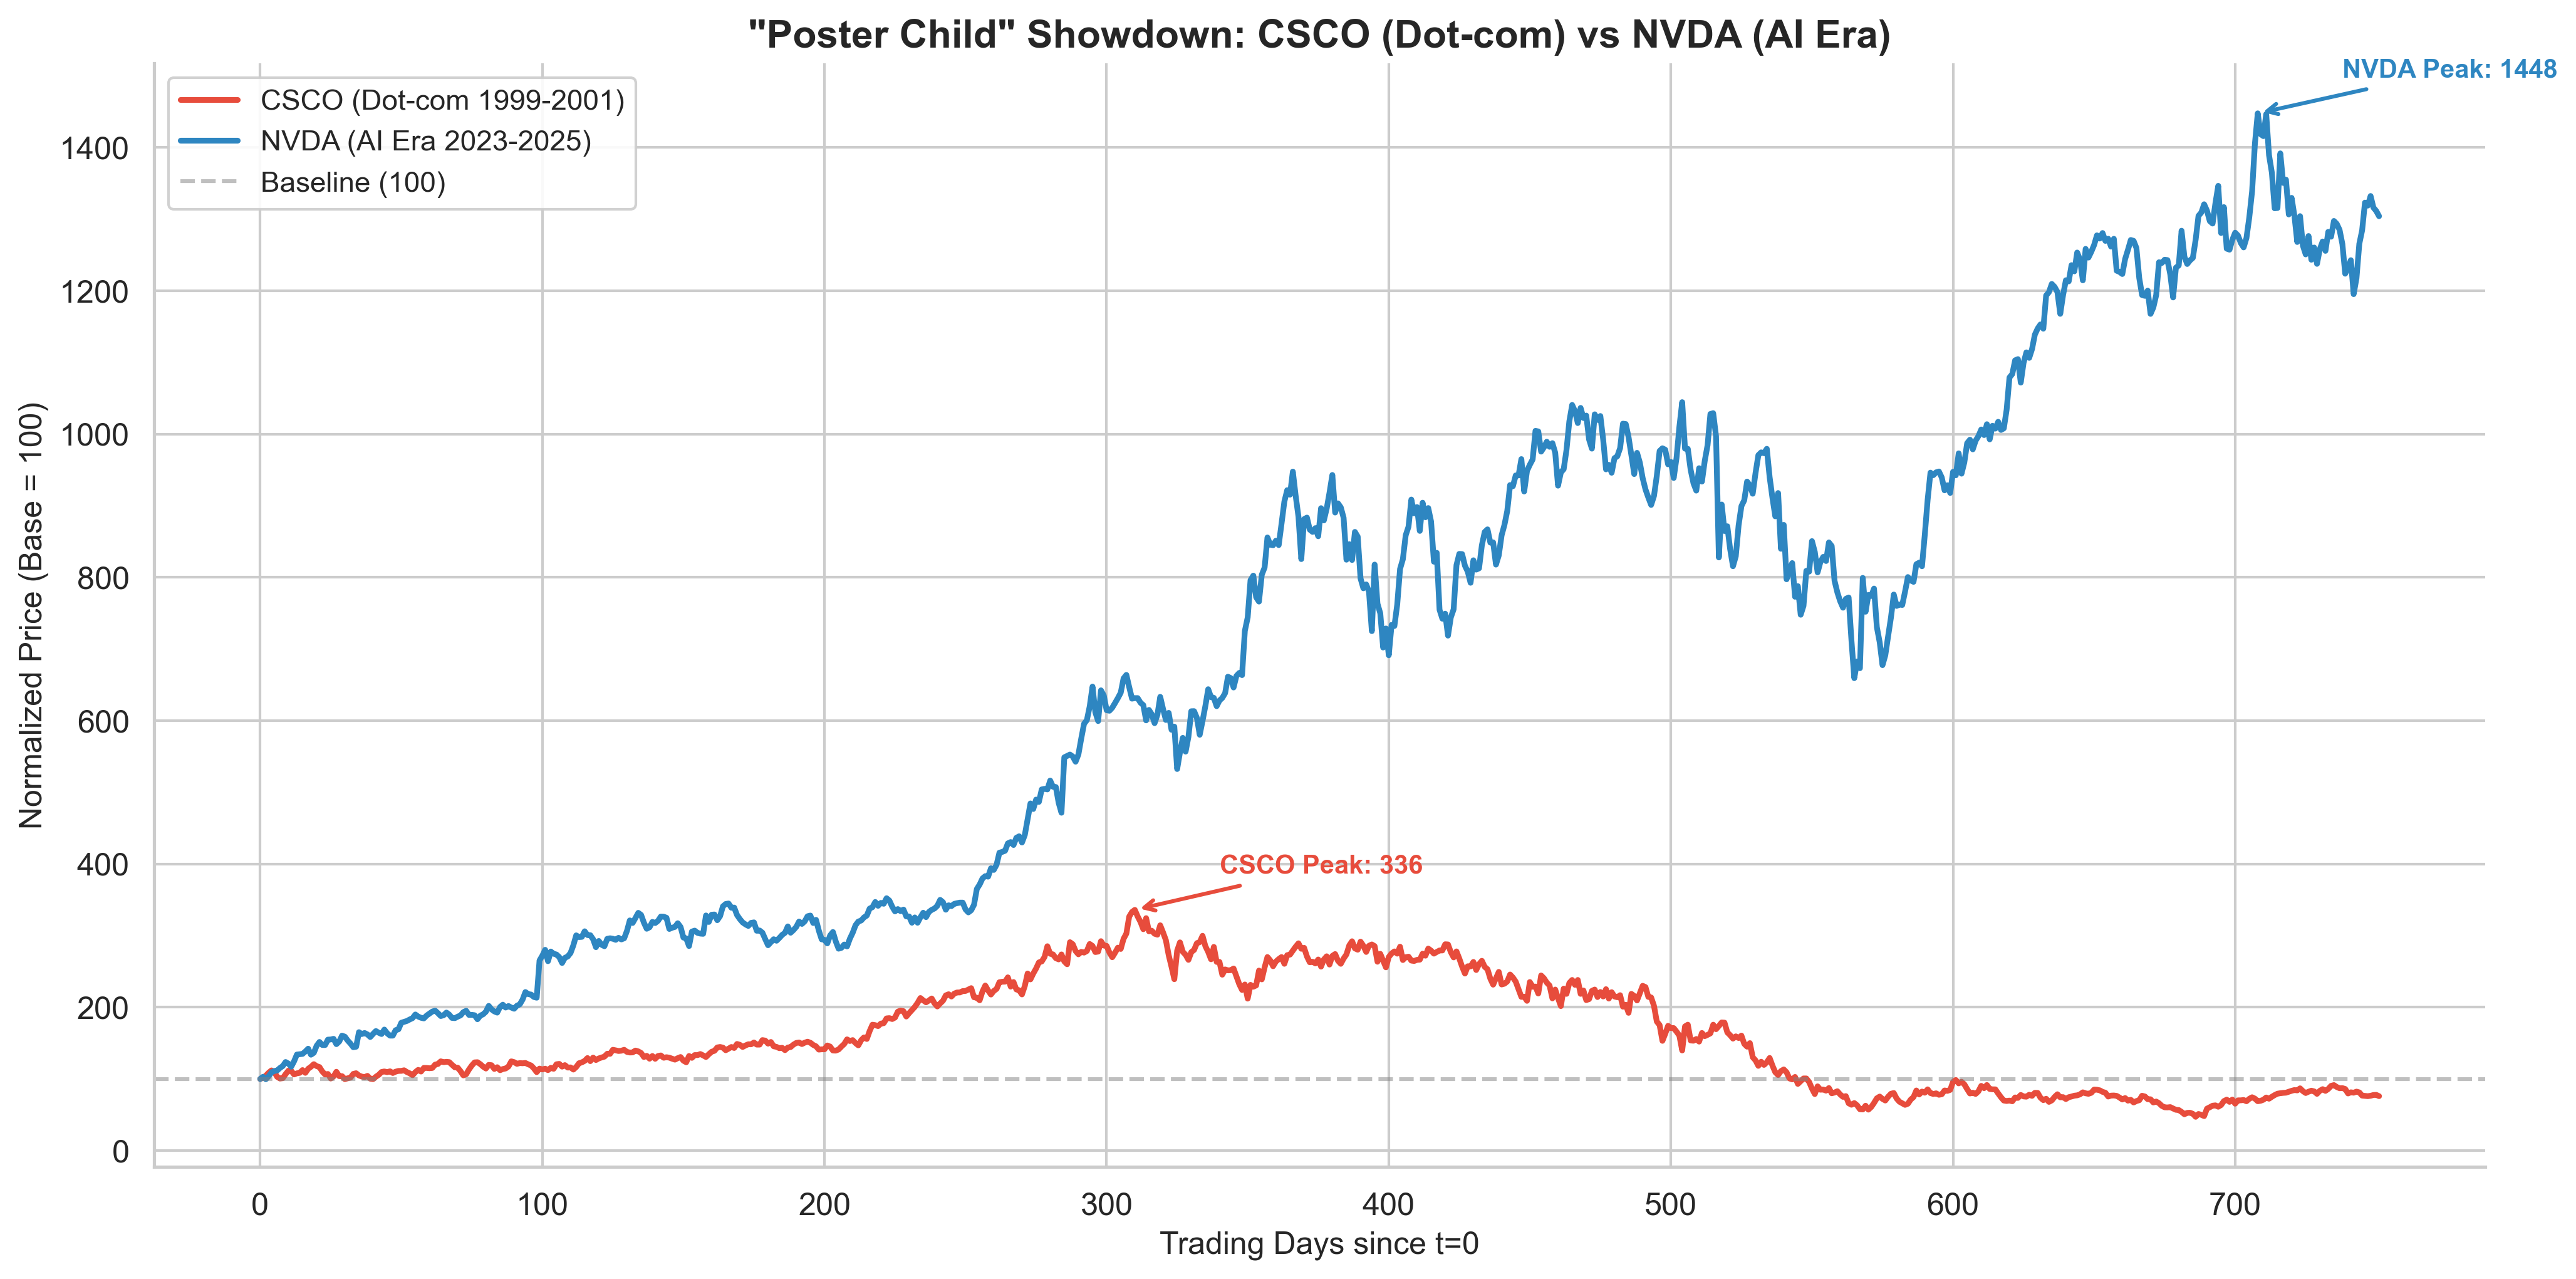

In [4]:
# Section 1: CSCO vs NVDA Overlay 
adf = aligned_df(dc_df['CSCO'], ai_df['NVDA'])

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(adf['Trading Day'], adf['Dot-com'], color=C_DOTCOM, linewidth=2.2, label='CSCO (Dot-com 1999-2001)')
ax.plot(adf['Trading Day'], adf['AI'], color=C_AI, linewidth=2.2, label='NVDA (AI Era 2023-2025)')

# Annotate Peaks
csco_peak_idx = adf['Dot-com'].idxmax()
nvda_peak_idx = adf['AI'].idxmax()

ax.annotate(f"CSCO Peak: {adf['Dot-com'].max():.0f}",
            xy=(adf.loc[csco_peak_idx, 'Trading Day'], adf['Dot-com'].max()),
            xytext=(adf.loc[csco_peak_idx, 'Trading Day'] + 30, adf['Dot-com'].max() + 50),
            fontsize=10, color=C_DOTCOM, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_DOTCOM, lw=1.5))

ax.annotate(f"NVDA Peak: {adf['AI'].max():.0f}",
            xy=(adf.loc[nvda_peak_idx, 'Trading Day'], adf['AI'].max()),
            xytext=(adf.loc[nvda_peak_idx, 'Trading Day'] + 30, adf['AI'].max() + 50),
            fontsize=10, color=C_AI, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_AI, lw=1.5))

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Baseline (100)')
ax.set_xlabel('Trading Days since t=0')
ax.set_ylabel('Normalized Price (Base = 100)')
ax.set_title('"Poster Child" Showdown: CSCO (Dot-com) vs NVDA (AI Era)')
ax.legend(loc='upper left', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
plt.tight_layout()
plt.savefig('figure1.png')
plt.show()

In [5]:
# Slope & Statistics Comparison 
csco_norm = normalize(dc_df['CSCO'].dropna())
nvda_norm = normalize(ai_df['NVDA'].dropna())

stats = pd.DataFrame({
    'Metric': [
        'Peak (Normalized)',
        'Peak Multiplier (x)',
        'Trading Days to Peak',
        'Avg Monthly Gain (%)',
        'Max Drawdown (%)',
        'Annualized Volatility (%)'
    ],
    'CSCO (Dot-com)': [
        f"{csco_norm.max():.1f}",
        f"{csco_norm.max()/100:.2f}x",
        f"{csco_norm.idxmax()} ({(csco_norm.idxmax() - csco_norm.index[0]).days} days)",
        f"{((csco_norm.max()/100) ** (252/(csco_norm.values.argmax()+1)) - 1) * 100:.1f}%",
        f"{calc_max_drawdown(dc_df['CSCO'])*100:.1f}%",
        f"{dc_df['CSCO'].pct_change().std() * (252**0.5) * 100:.1f}%"
    ],
    'NVDA (AI Era)': [
        f"{nvda_norm.max():.1f}",
        f"{nvda_norm.max()/100:.2f}x",
        f"{nvda_norm.idxmax()} ({(nvda_norm.idxmax() - nvda_norm.index[0]).days} days)",
        f"{((nvda_norm.max()/100) ** (252/(nvda_norm.values.argmax()+1)) - 1) * 100:.1f}%",
        f"{calc_max_drawdown(ai_df['NVDA'])*100:.1f}%",
        f"{ai_df['NVDA'].pct_change().std() * (252**0.5) * 100:.1f}%"
    ]
})
stats.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Metric,CSCO (Dot-com),NVDA (AI Era)
Peak (Normalized),336.0,1447.7
Peak Multiplier (x),3.36x,14.48x
Trading Days to Peak,2000-03-27 00:00:00 (448 days),2025-10-29 00:00:00 (1030 days)
Avg Monthly Gain (%),167.0%,158.5%
Max Drawdown (%),-86.0%,-36.9%
Annualized Volatility (%),66.4%,50.2%


**Key Observations:**
- Compare the **Peak Multiplier** of both stocks: a higher multiplier indicates a more intense rally
- Check the **Avg Monthly Gain**: if NVDA is higher than CSCO, the current hype cycle is faster and stronger
- Note the **Max Drawdown**: despite CSCO's massive rally, it ultimately fell over 80% from its peak
- Critical question: **Where is NVDA in its cycle?** Before or after the peak?

---
# 2. The "Infrastructure" Parallel — Hardware Group

> Comparing **chip/hardware builders** across both eras

| Dot-com Hardware | AI Hardware |
|:---:|:---:|
| INTC (Intel), QCOM (Qualcomm) | AMD, NVDA |

**Key Question:** Did Dot-com hardware stocks rally together across the board? Is NVDA carrying the AI sector alone, or is AMD following closely?

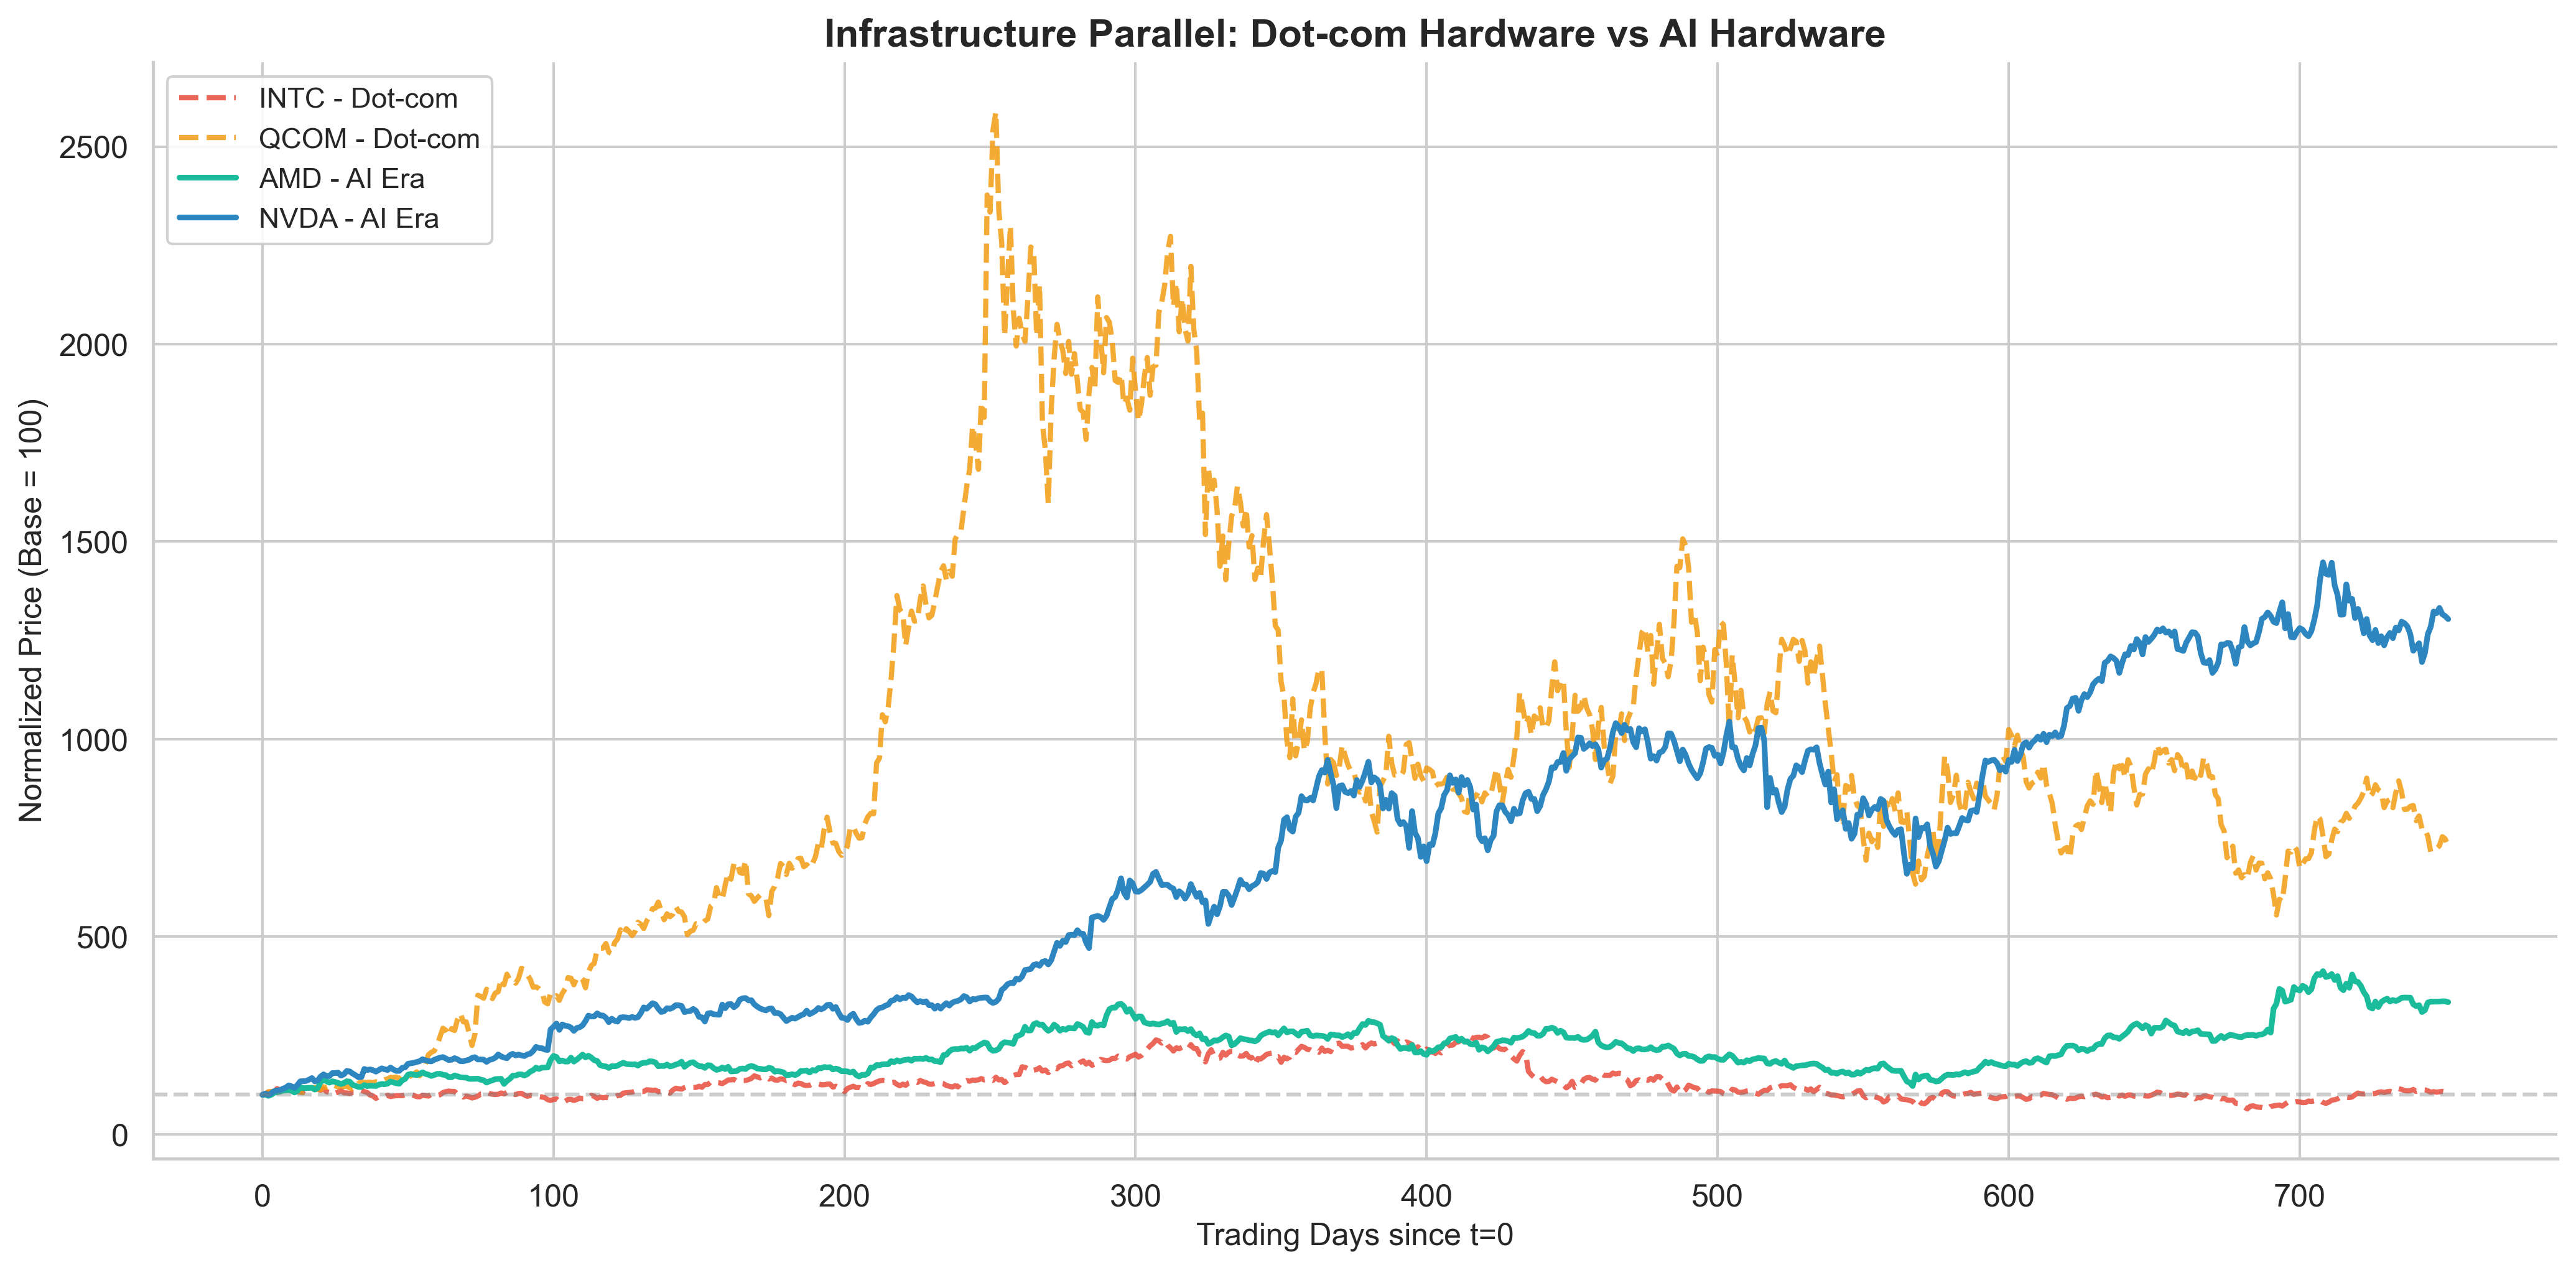

In [6]:
# Section 2: Infrastructure Parallel
min_len = min(len(dc_df), len(ai_df))

fig, ax = plt.subplots(figsize=(14, 7))

# Dot-com hardware 
intc_n = normalize(dc_df['INTC'].iloc[:min_len])
qcom_n = normalize(dc_df['QCOM'].iloc[:min_len])
ax.plot(range(min_len), intc_n.values, color=C_DOTCOM, linewidth=2, linestyle='--',
        label='INTC - Dot-com', alpha=0.85)
ax.plot(range(min_len), qcom_n.values, color=C_DOTCOM2, linewidth=2, linestyle='--',
        label='QCOM - Dot-com', alpha=0.85)

# AI hardware 
amd_n = normalize(ai_df['AMD'].iloc[:min_len])
nvda_n = normalize(ai_df['NVDA'].iloc[:min_len])
ax.plot(range(min_len), amd_n.values, color=C_AI2, linewidth=2.2,
        label='AMD - AI Era')
ax.plot(range(min_len), nvda_n.values, color=C_AI, linewidth=2.2,
        label='NVDA - AI Era')

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Trading Days since t=0')
ax.set_ylabel('Normalized Price (Base = 100)')
ax.set_title('Infrastructure Parallel: Dot-com Hardware vs AI Hardware')
ax.legend(loc='upper left', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
plt.tight_layout()
plt.savefig('figure2.png')
plt.show()

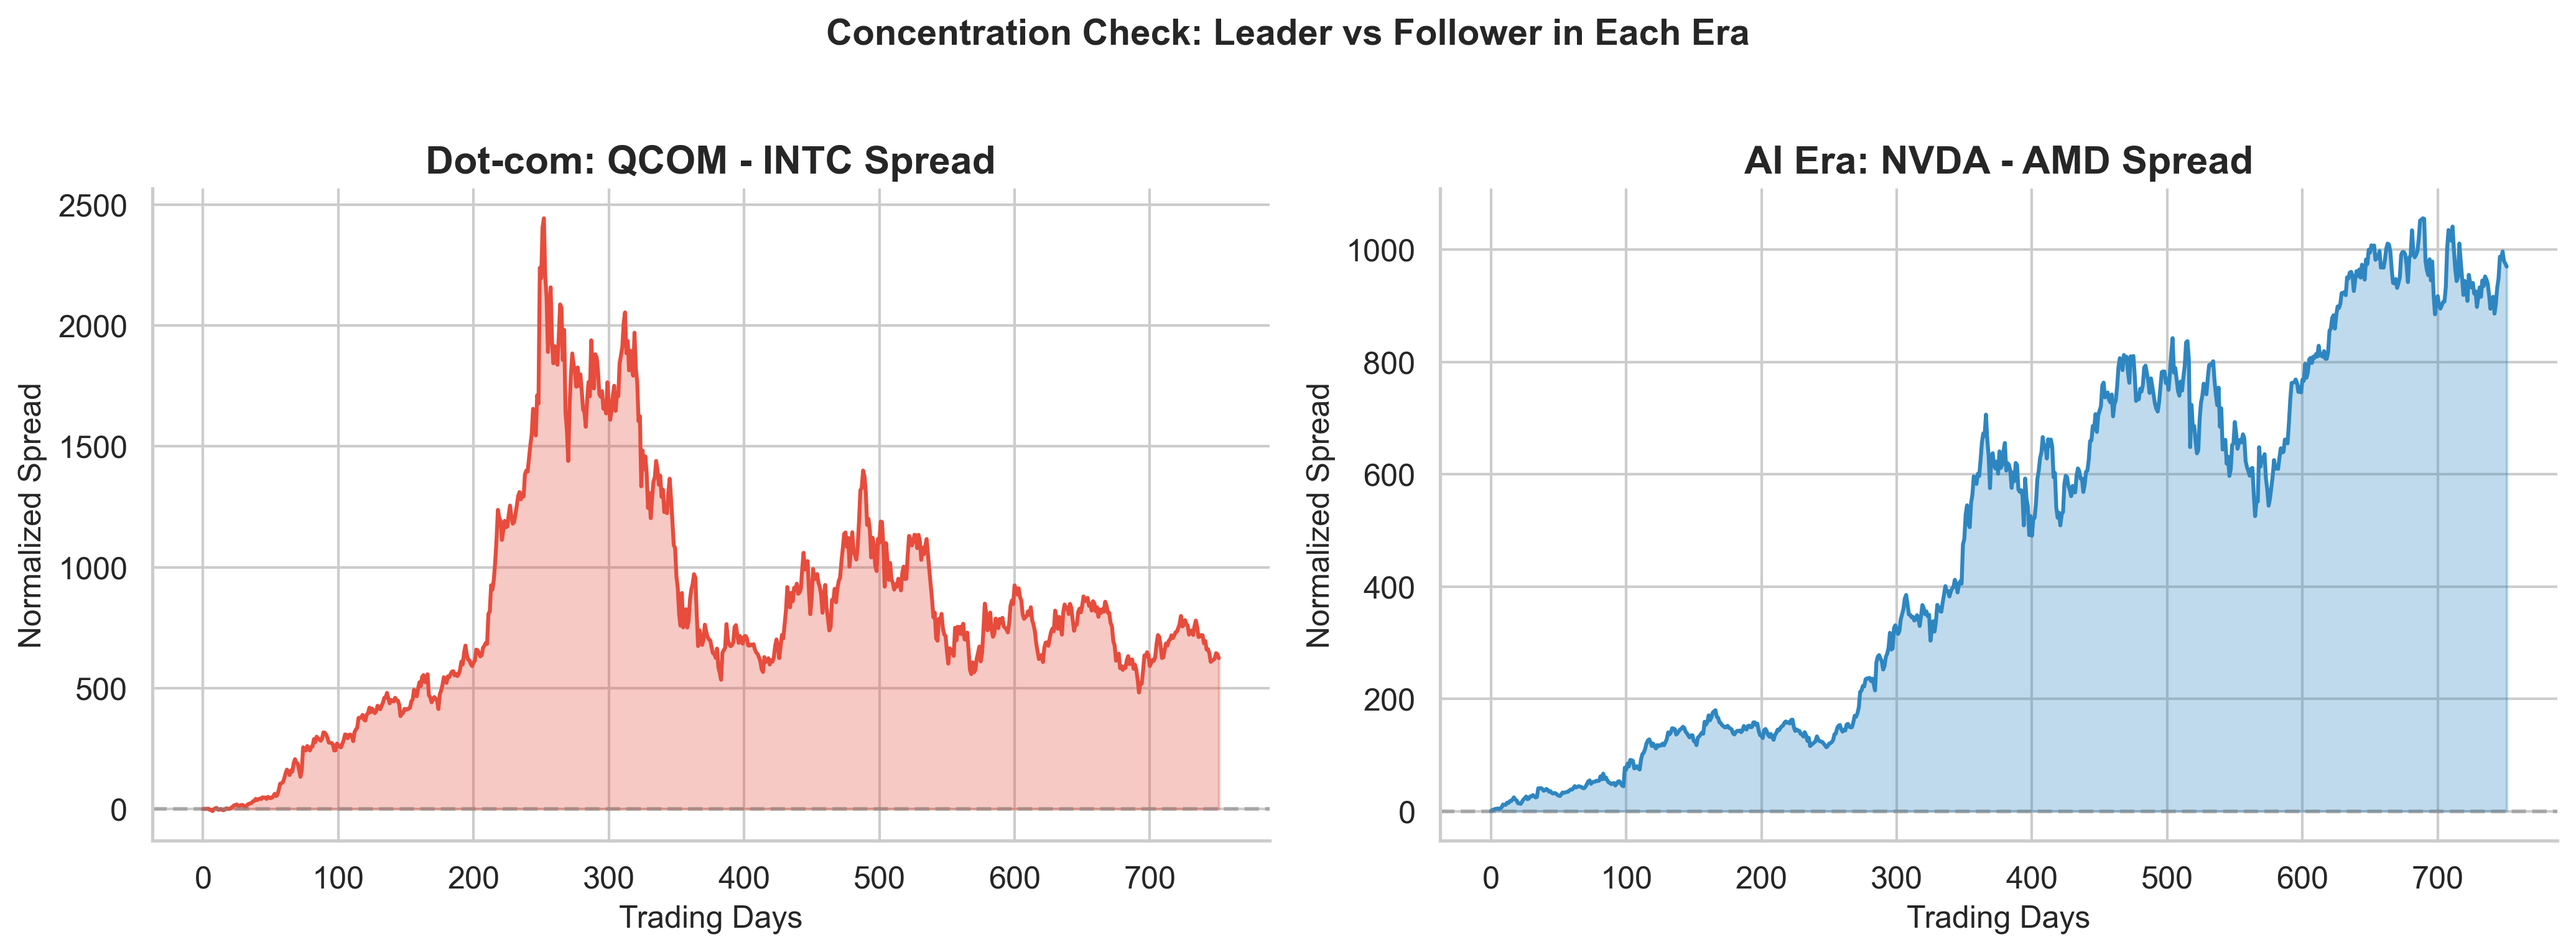

Dot-com Max Spread (QCOM - INTC): 2443 pts
AI Era  Max Spread (NVDA - AMD) : 1056 pts

Dot-com had higher concentration -> AI Era is more diversified


In [7]:
# Spread Analysis: Leader vs Follower
# Calculate the "Spread" between the leader and follower in each era

dc_spread = normalize(dc_df['QCOM']) - normalize(dc_df['INTC'])
ai_spread = normalize(ai_df['NVDA']) - normalize(ai_df['AMD'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].fill_between(range(len(dc_spread)), dc_spread.values, alpha=0.3, color=C_DOTCOM)
axes[0].plot(dc_spread.values, color=C_DOTCOM, linewidth=1.5)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Dot-com: QCOM - INTC Spread')
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Normalized Spread')

axes[1].fill_between(range(len(ai_spread)), ai_spread.values, alpha=0.3, color=C_AI)
axes[1].plot(ai_spread.values, color=C_AI, linewidth=1.5)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('AI Era: NVDA - AMD Spread')
axes[1].set_xlabel('Trading Days')
axes[1].set_ylabel('Normalized Spread')

fig.suptitle('Concentration Check: Leader vs Follower in Each Era', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure3.png')
plt.show()

print(f"Dot-com Max Spread (QCOM - INTC): {dc_spread.max():.0f} pts")
print(f"AI Era  Max Spread (NVDA - AMD) : {ai_spread.max():.0f} pts")
print()
if ai_spread.max() > dc_spread.max():
    print("[WARNING] AI Era shows HIGHER concentration than Dot-com")
    print("  -> NVDA is carrying more weight than QCOM ever did during Dot-com")
else:
    print("Dot-com had higher concentration -> AI Era is more diversified")

**Key Observations:**
- Dot-com era: QCOM rallied the hardest, but INTC followed closely — the rally was relatively **broad-based**
- AI era: NVDA surged dramatically while AMD lagged **far behind** — the rally is **highly concentrated**
- **Risk implication:** When the market depends on a single stock (NVDA), any stumble in that stock impacts the entire sector

---
# 3. The "Survivors" Reflection — AMZN, MSFT, ORCL

> **Lessons from the Survivors:** Companies that lived through both eras

We compare stock prices of AMZN, MSFT, and ORCL across both the Dot-com and AI periods to answer: **"Even a great company can be a terrible investment if you buy at the wrong price."**

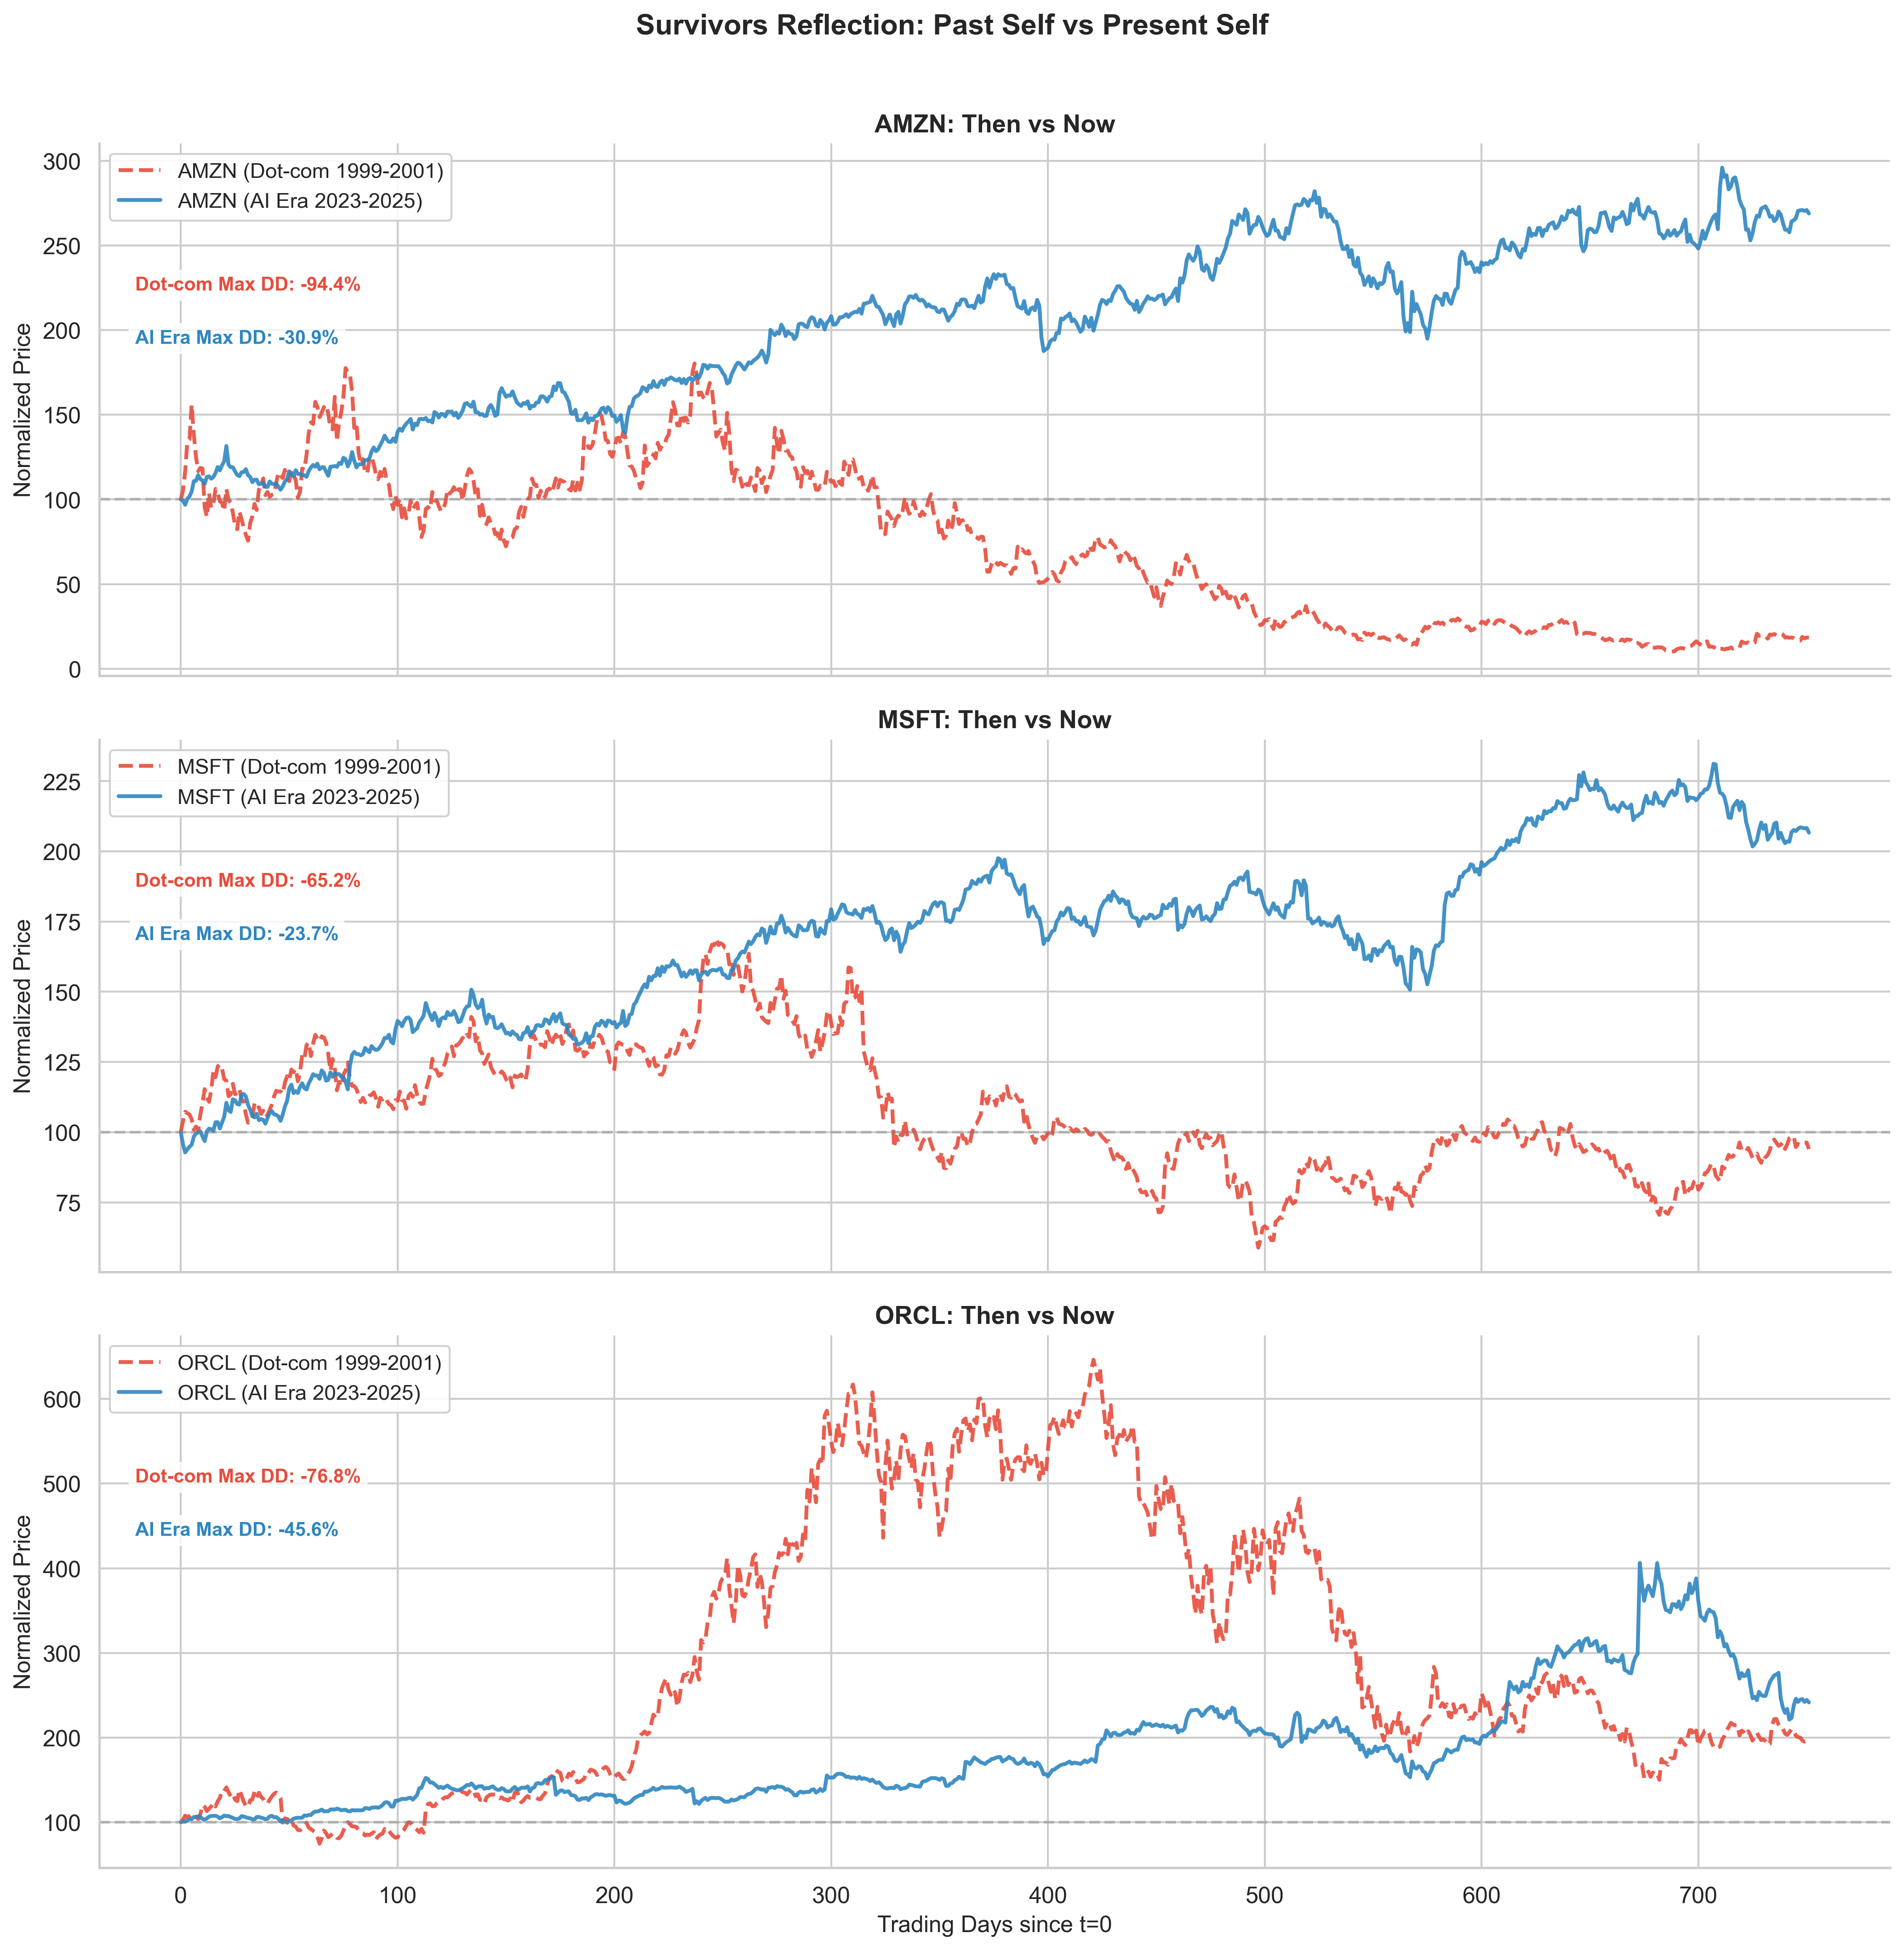

In [8]:
# Section 3: Survivors Reflection
survivors = ['AMZN', 'MSFT', 'ORCL']

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

for i, ticker in enumerate(survivors):
    ax = axes[i]
    dc_s = normalize(dc_df[ticker].dropna())
    ai_s = normalize(ai_df[ticker].dropna())
    min_len = min(len(dc_s), len(ai_s))

    ax.plot(range(min_len), dc_s.values[:min_len], color=C_DOTCOM, linewidth=2,
            linestyle='--', label=f'{ticker} (Dot-com 1999-2001)', alpha=0.9)
    ax.plot(range(min_len), ai_s.values[:min_len], color=C_AI, linewidth=2,
            label=f'{ticker} (AI Era 2023-2025)', alpha=0.9)

    # Annotate max drawdown for Dot-com
    dd = calc_max_drawdown(dc_df[ticker])
    ax.text(0.02, 0.75, f'Dot-com Max DD: {dd*100:.1f}%',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=10, color=C_DOTCOM, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    dd_ai = calc_max_drawdown(ai_df[ticker])
    ax.text(0.02, 0.65, f'AI Era Max DD: {dd_ai*100:.1f}%',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=10, color=C_AI, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4)
    ax.set_ylabel('Normalized Price')
    ax.set_title(f'{ticker}: Then vs Now', fontsize=13)
    ax.legend(loc='upper left', framealpha=0.9)

axes[-1].set_xlabel('Trading Days since t=0')
fig.suptitle('Survivors Reflection: Past Self vs Present Self',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure4.png')
plt.show()

In [9]:
# Survivors Summary Table
rows = []
for ticker in survivors:
    dc_norm = normalize(dc_df[ticker].dropna())
    ai_norm = normalize(ai_df[ticker].dropna())
    rows.append({
        'Ticker': ticker,
        'Dot-com Peak': f"{dc_norm.max():.0f}",
        'Dot-com Max DD': f"{calc_max_drawdown(dc_df[ticker])*100:.1f}%",
        'Dot-com Final': f"{dc_norm.iloc[-1]:.0f}",
        'AI Peak': f"{ai_norm.max():.0f}",
        'AI Max DD': f"{calc_max_drawdown(ai_df[ticker])*100:.1f}%",
        'AI Final': f"{ai_norm.iloc[-1]:.0f}",
    })

survivor_stats = pd.DataFrame(rows)
survivor_stats.style.set_properties(**{'text-align': 'center'}).hide(axis='index')

Ticker,Dot-com Peak,Dot-com Max DD,Dot-com Final,AI Peak,AI Max DD,AI Final
AMZN,180,-94.4%,18,296,-30.9%,269
MSFT,169,-65.2%,94,231,-23.7%,207
ORCL,646,-76.8%,193,406,-45.6%,242


**Key Observations:**
- **AMZN** during Dot-com: rallied hard but eventually crashed — investors who bought at the peak had to wait **nearly 10 years** to break even
- **MSFT** during Dot-com: despite being a great company, it still suffered a severe drawdown
- **ORCL**: experienced the worst drawdown in the group due to extreme valuation before the bubble burst

**Lesson:** *'Being right about the company doesn't protect you from being wrong about the price.'*

# 4. The "Speculative" Check — MSTR vs PLTR

> **Speculative stocks**: The ultimate measure of market frenzy

| Dot-com Spec | AI Spec |
|:---:|:---:|
| MicroStrategy (MSTR) | Palantir (PLTR) |

MSTR during Dot-com famously surged from $70 to $3,000 then collapsed to $10 — all within a single year.

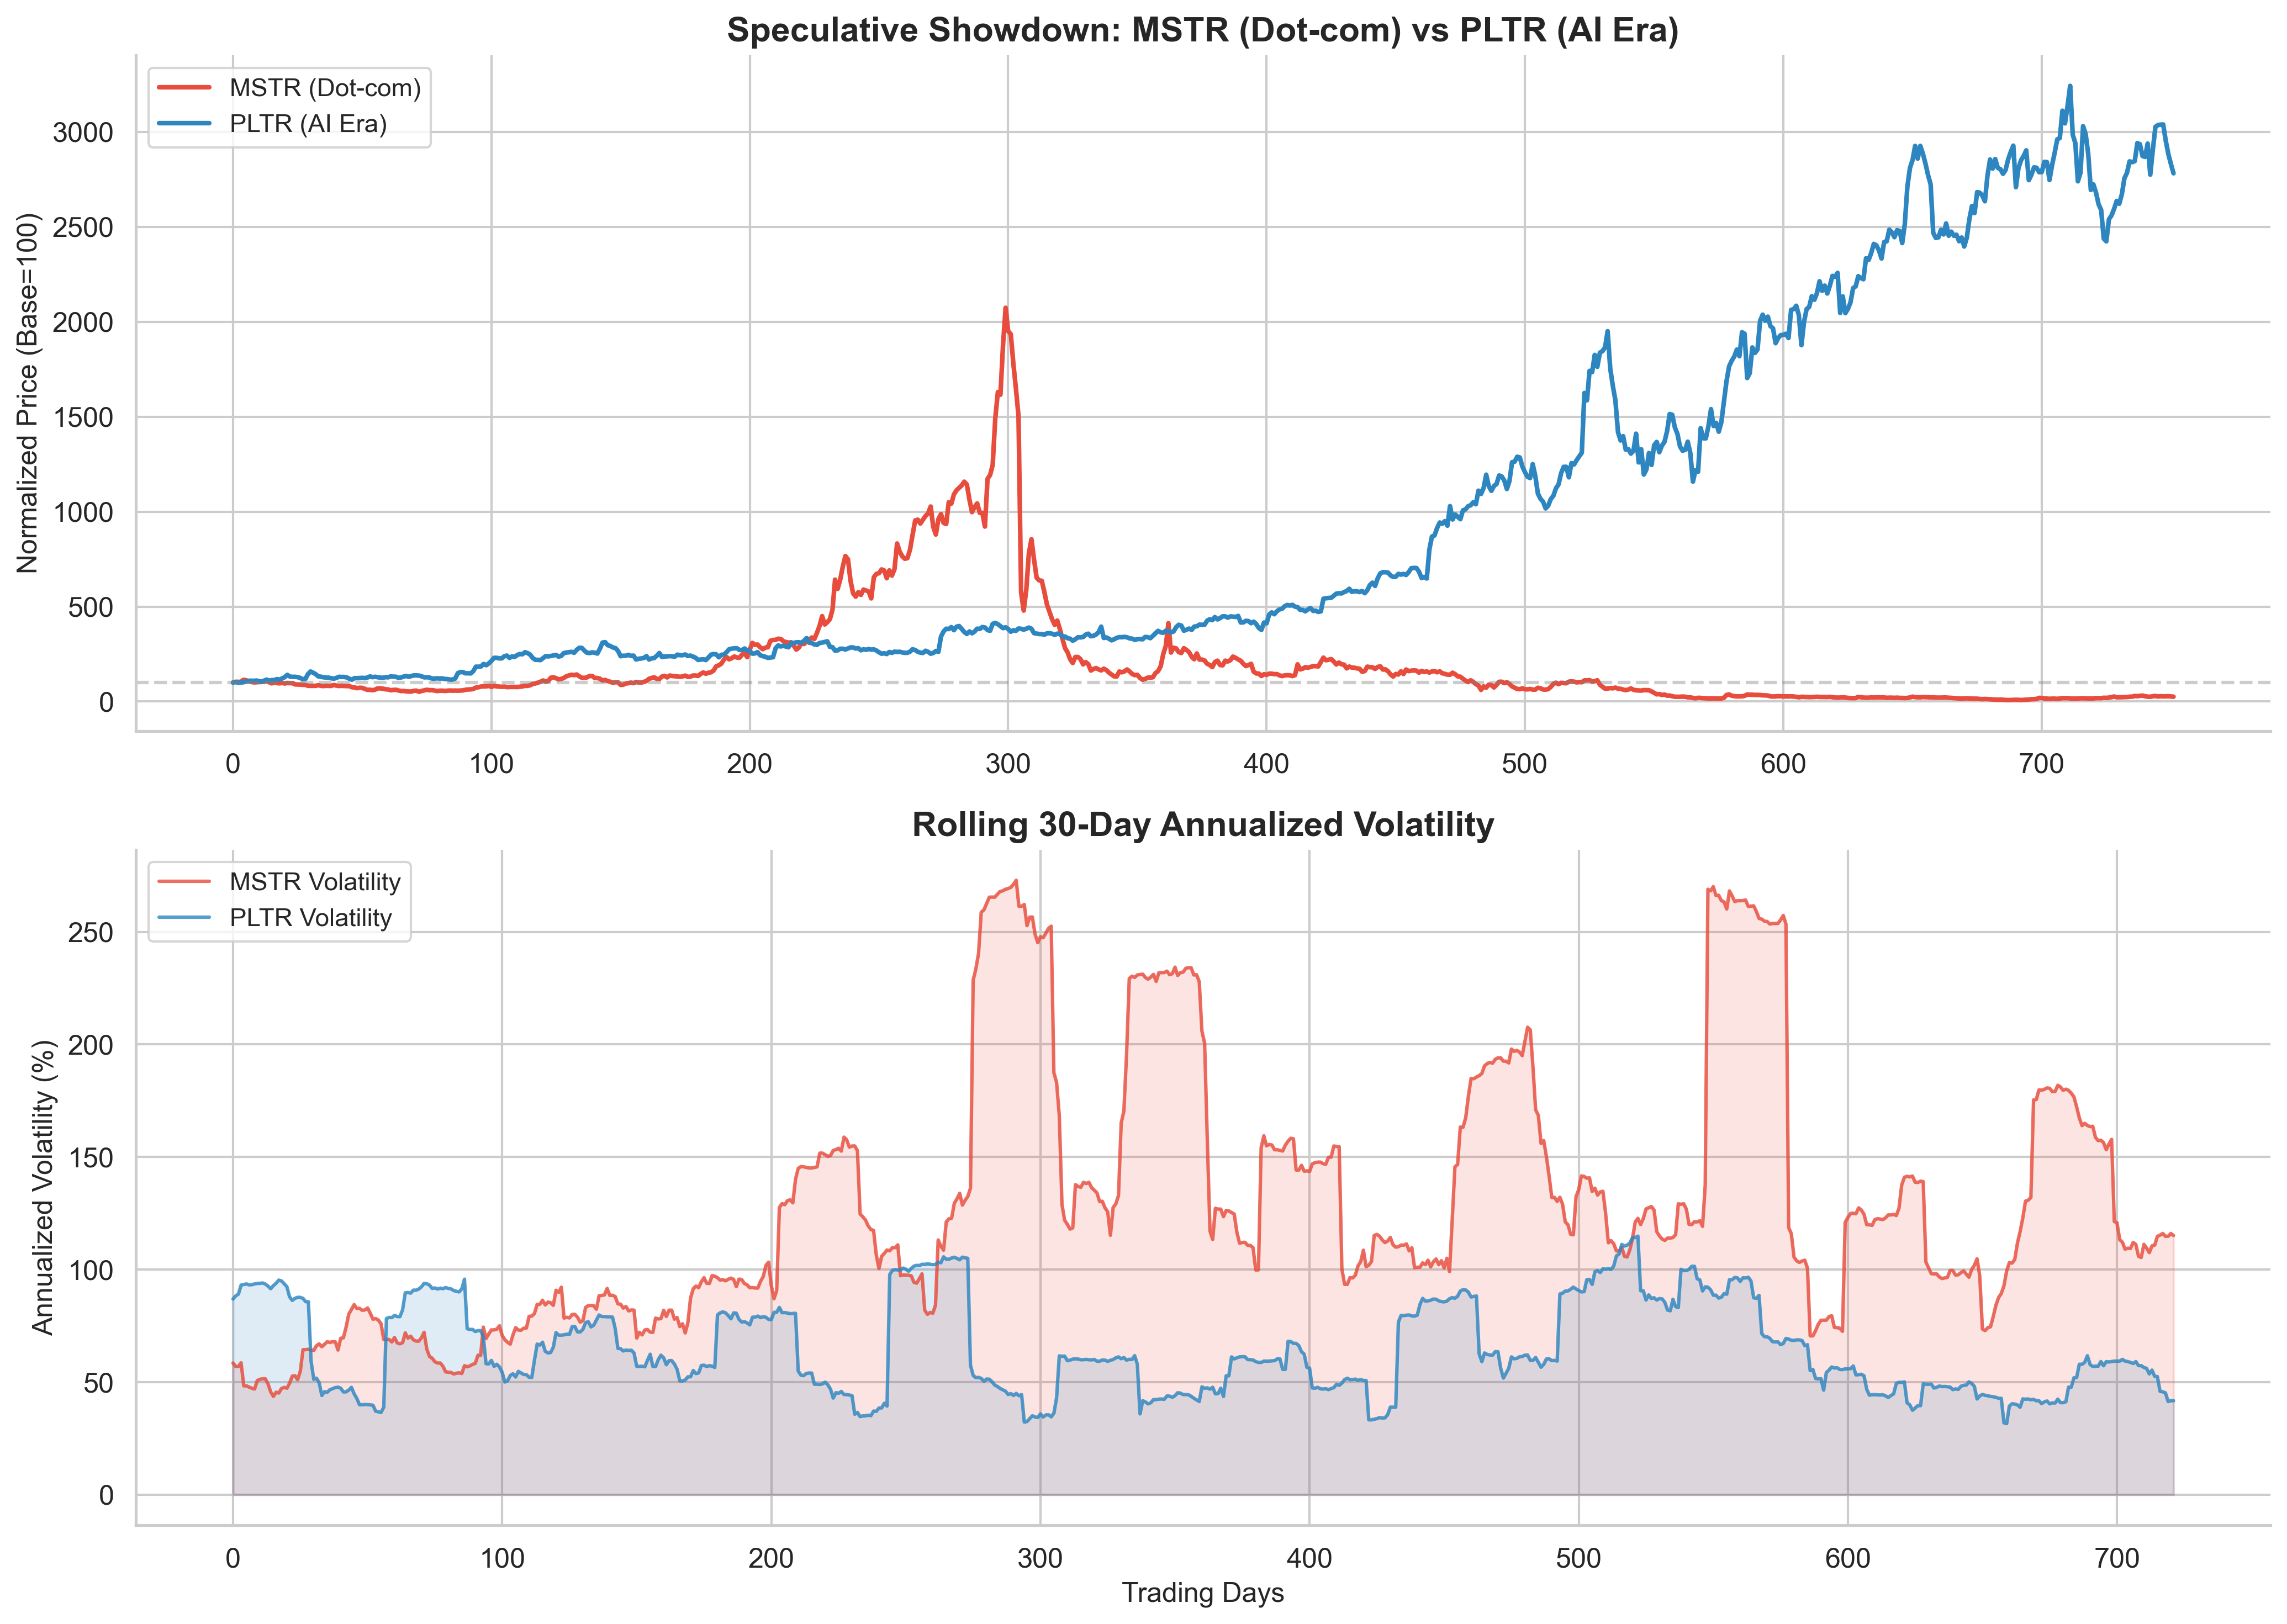

In [10]:
# Section 4: Speculative Check
adf_spec = aligned_df(dc_df['MSTR'], ai_df['PLTR'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Chart 1: Normalized Price Overlay 
ax = axes[0]
ax.plot(adf_spec['Trading Day'], adf_spec['Dot-com'], color=C_DOTCOM, linewidth=2,
        label='MSTR (Dot-com)')
ax.plot(adf_spec['Trading Day'], adf_spec['AI'], color=C_AI, linewidth=2,
        label='PLTR (AI Era)')
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4)
ax.set_ylabel('Normalized Price (Base=100)')
ax.set_title('Speculative Showdown: MSTR (Dot-com) vs PLTR (AI Era)')
ax.legend(loc='upper left')

# Chart 2: Rolling 30-day Volatility 
ax2 = axes[1]
mstr_vol = dc_df['MSTR'].pct_change().rolling(30).std() * (252**0.5) * 100
pltr_vol = ai_df['PLTR'].pct_change().rolling(30).std() * (252**0.5) * 100

min_vol_len = min(len(mstr_vol.dropna()), len(pltr_vol.dropna()))
ax2.plot(range(min_vol_len), mstr_vol.dropna().values[:min_vol_len], color=C_DOTCOM,
         linewidth=1.5, alpha=0.8, label='MSTR Volatility')
ax2.plot(range(min_vol_len), pltr_vol.dropna().values[:min_vol_len], color=C_AI,
         linewidth=1.5, alpha=0.8, label='PLTR Volatility')
ax2.fill_between(range(min_vol_len), mstr_vol.dropna().values[:min_vol_len],
                 alpha=0.15, color=C_DOTCOM)
ax2.fill_between(range(min_vol_len), pltr_vol.dropna().values[:min_vol_len],
                 alpha=0.15, color=C_AI)
ax2.set_xlabel('Trading Days')
ax2.set_ylabel('Annualized Volatility (%)')
ax2.set_title('Rolling 30-Day Annualized Volatility')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig('figure5.png')
plt.show()

In [11]:
# Speculative Stats
mstr_ret = dc_df['MSTR'].pct_change().dropna()
pltr_ret = ai_df['PLTR'].pct_change().dropna()

spec_stats = pd.DataFrame({
    'Metric': [
        'Peak Multiplier (x)',
        'Max Drawdown (%)',
        'Max Single-Day Gain (%)',
        'Max Single-Day Loss (%)',
        'Annualized Volatility (%)',
        'Days with |move| > 10%'
    ],
    'MSTR (Dot-com)': [
        f"{normalize(dc_df['MSTR']).max()/100:.1f}x",
        f"{calc_max_drawdown(dc_df['MSTR'])*100:.1f}%",
        f"{mstr_ret.max()*100:.1f}%",
        f"{mstr_ret.min()*100:.1f}%",
        f"{mstr_ret.std()*(252**0.5)*100:.1f}%",
        f"{(mstr_ret.abs() > 0.10).sum()} days"
    ],
    'PLTR (AI Era)': [
        f"{normalize(ai_df['PLTR']).max()/100:.1f}x",
        f"{calc_max_drawdown(ai_df['PLTR'])*100:.1f}%",
        f"{pltr_ret.max()*100:.1f}%",
        f"{pltr_ret.min()*100:.1f}%",
        f"{pltr_ret.std()*(252**0.5)*100:.1f}%",
        f"{(pltr_ret.abs() > 0.10).sum()} days"
    ]
})
spec_stats.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Metric,MSTR (Dot-com),PLTR (AI Era)
Peak Multiplier (x),20.7x,32.4x
Max Drawdown (%),-99.6%,-40.6%
Max Single-Day Gain (%),76.4%,30.8%
Max Single-Day Loss (%),-61.7%,-15.1%
Annualized Volatility (%),139.6%,66.9%
Days with |move| > 10%,123 days,22 days


**Key Observations:**
- **MSTR** during Dot-com was the ultimate example of Retail Frenzy — extreme Peak Multiplier followed by devastating drawdown
- Compare **Annualized Volatility**: if PLTR is close to MSTR levels, it signals similar speculative intensity
- The number of **days with price moves exceeding 10%** is a clear indicator of "frenzy level"

---
# 5. Index Overlay — NASDAQ Benchmark

> Comparing **NASDAQ Composite (^IXIC)** across both eras to assess whether the **overall market** is overheating to the same degree

This is the **Macro View** — not just individual stocks, but the "temperature" of the entire market.

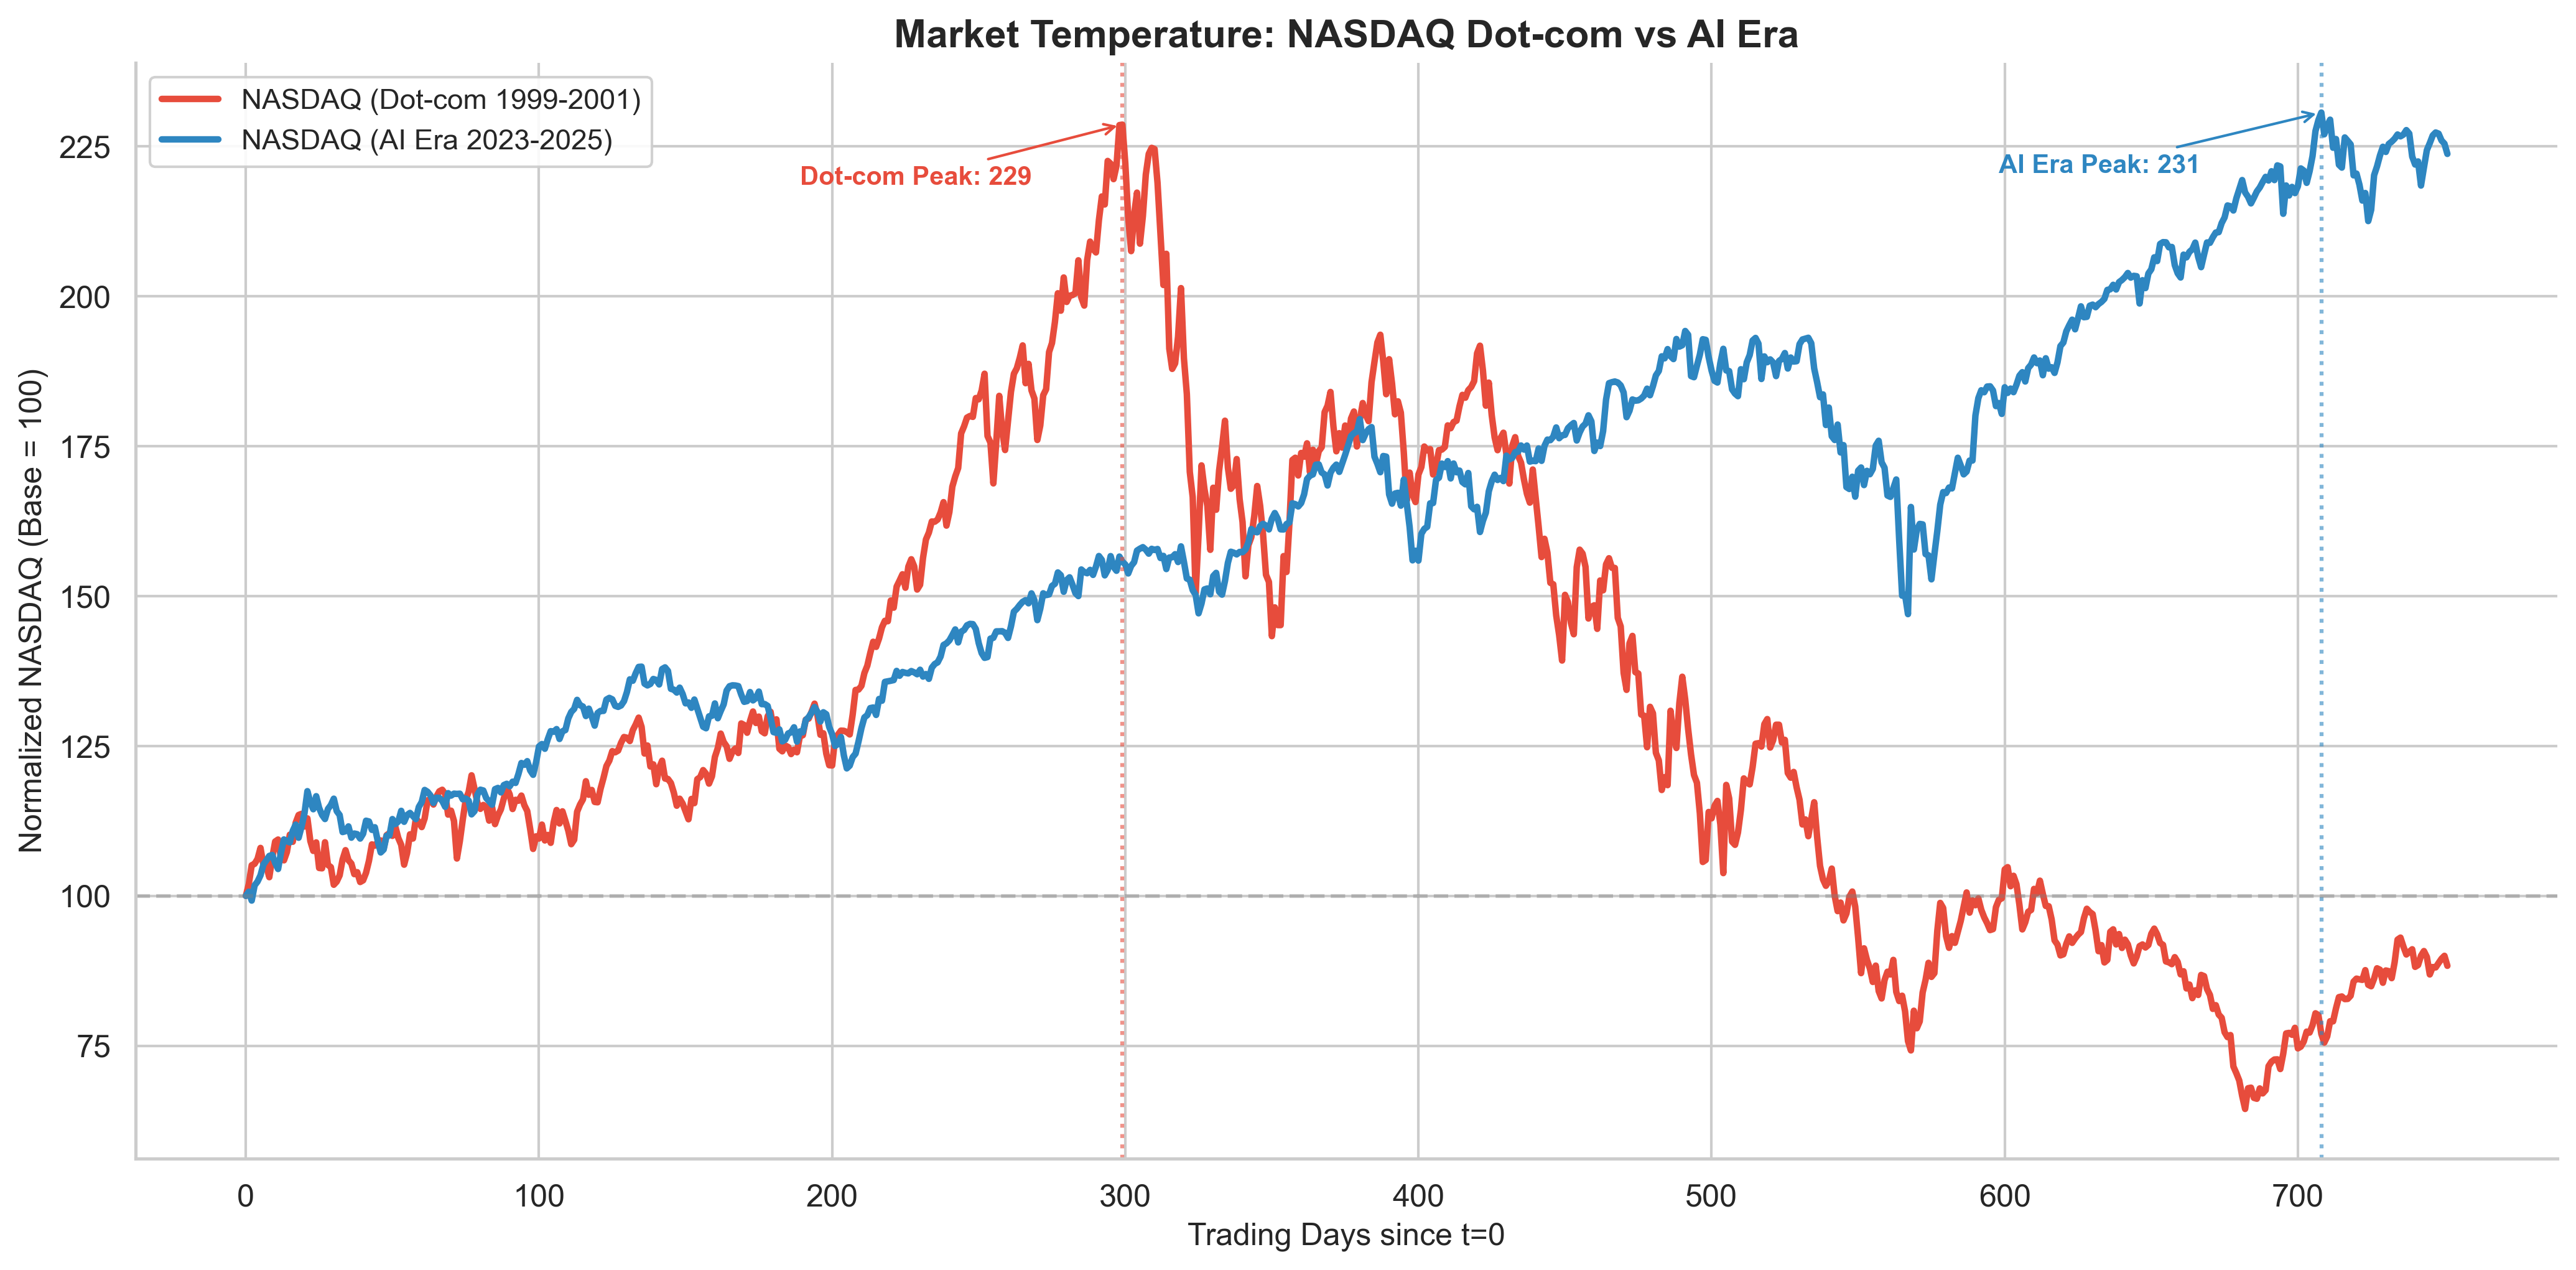

In [12]:
# Section 5: NASDAQ Index Overlay
adf_idx = aligned_df(dc_df['^IXIC'], ai_df['^IXIC'])

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(adf_idx['Trading Day'], adf_idx['Dot-com'], color=C_DOTCOM, linewidth=2.5,
        label='NASDAQ (Dot-com 1999-2001)')
ax.plot(adf_idx['Trading Day'], adf_idx['AI'], color=C_AI, linewidth=2.5,
        label='NASDAQ (AI Era 2023-2025)')

# Highlight Peak Zone
dc_peak_day = adf_idx['Dot-com'].idxmax()
ai_peak_day = adf_idx['AI'].idxmax()

ax.axvline(x=adf_idx.loc[dc_peak_day, 'Trading Day'], color=C_DOTCOM,
           linestyle=':', alpha=0.6, linewidth=1.5)
ax.axvline(x=adf_idx.loc[ai_peak_day, 'Trading Day'], color=C_AI,
           linestyle=':', alpha=0.6, linewidth=1.5)

ax.annotate(f"Dot-com Peak: {adf_idx['Dot-com'].max():.0f}",
            xy=(adf_idx.loc[dc_peak_day, 'Trading Day'], adf_idx['Dot-com'].max()),
            xytext=(adf_idx.loc[dc_peak_day, 'Trading Day'] - 110, adf_idx['Dot-com'].max() - 10),
            fontsize=10, color=C_DOTCOM, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_DOTCOM))

ax.annotate(f"AI Era Peak: {adf_idx['AI'].max():.0f}",
            xy=(adf_idx.loc[ai_peak_day, 'Trading Day'], adf_idx['AI'].max()),
            xytext=(adf_idx.loc[ai_peak_day, 'Trading Day'] - 110, adf_idx['AI'].max() - 10),
            fontsize=10, color=C_AI, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_AI))

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Trading Days since t=0')
ax.set_ylabel('Normalized NASDAQ (Base = 100)')
ax.set_title('Market Temperature: NASDAQ Dot-com vs AI Era')
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('figure6.png')
plt.show()

In [13]:
# NASDAQ Stats Comparison
dc_nasdaq = dc_df['^IXIC']
ai_nasdaq = ai_df['^IXIC']

idx_stats = pd.DataFrame({
    'Metric': [
        'Starting Value',
        'Peak Value',
        'Peak Multiplier (x)',
        'Max Drawdown (%)',
        'CAGR (%)',
        'Annualized Volatility (%)',
        'Sharpe-like (CAGR/Vol)',
    ],
    'NASDAQ (Dot-com)': [
        f"{dc_nasdaq.iloc[0]:,.0f}",
        f"{dc_nasdaq.max():,.0f}",
        f"{dc_nasdaq.max()/dc_nasdaq.iloc[0]:.2f}x",
        f"{calc_max_drawdown(dc_nasdaq)*100:.1f}%",
        f"{calc_cagr(dc_nasdaq)*100:.1f}%",
        f"{dc_nasdaq.pct_change().std()*(252**0.5)*100:.1f}%",
        f"{calc_cagr(dc_nasdaq)/(dc_nasdaq.pct_change().std()*(252**0.5)):.2f}",
    ],
    'NASDAQ (AI Era)': [
        f"{ai_nasdaq.iloc[0]:,.0f}",
        f"{ai_nasdaq.max():,.0f}",
        f"{ai_nasdaq.max()/ai_nasdaq.iloc[0]:.2f}x",
        f"{calc_max_drawdown(ai_nasdaq)*100:.1f}%",
        f"{calc_cagr(ai_nasdaq)*100:.1f}%",
        f"{ai_nasdaq.pct_change().std()*(252**0.5)*100:.1f}%",
        f"{calc_cagr(ai_nasdaq)/(ai_nasdaq.pct_change().std()*(252**0.5)):.2f}",
    ]
})
idx_stats.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Metric,NASDAQ (Dot-com),NASDAQ (AI Era)
Starting Value,"2,208","10,387"
Peak Value,"5,049","23,958"
Peak Multiplier (x),2.29x,2.31x
Max Drawdown (%),-71.8%,-24.3%
CAGR (%),-4.1%,31.0%
Annualized Volatility (%),41.0%,20.2%
Sharpe-like (CAGR/Vol),-0.10,1.54


**Key Observations:**
- Compare the **Peak Multiplier** of NASDAQ across both eras: the Dot-com index surged roughly 2.5x before collapsing
- **Max Drawdown** during Dot-com: NASDAQ fell over **-70%** from its peak
- The **Sharpe-like ratio** helps assess whether the returns were "worth the risk"
- If the AI Era peak multiplier approaches Dot-com levels, the market may be overheating to a similar degree

---
# 6. Summary & Key Findings

## Overall Comparison Matrix

In [14]:
# Section 6: Grand Summary
summary_data = {
    'Category': [
        'Poster Child',
        'Infrastructure (Leader)',
        'Infrastructure (Follower)',
        'Survivor: AMZN',
        'Survivor: MSFT',
        'Survivor: ORCL',
        'Speculative',
        'NASDAQ Index'
    ],
    'Dot-com Ticker': ['CSCO', 'QCOM', 'INTC', 'AMZN', 'MSFT', 'ORCL', 'MSTR', '^IXIC'],
    'AI Ticker': ['NVDA', 'NVDA', 'AMD', 'AMZN', 'MSFT', 'ORCL', 'PLTR', '^IXIC'],
}

# Calculate metrics
dc_peaks = []
ai_peaks = []
dc_dds = []
ai_dds = []

dc_tickers = ['CSCO', 'QCOM', 'INTC', 'AMZN', 'MSFT', 'ORCL', 'MSTR', '^IXIC']
ai_tickers = ['NVDA', 'NVDA', 'AMD', 'AMZN', 'MSFT', 'ORCL', 'PLTR', '^IXIC']

for dc_t, ai_t in zip(dc_tickers, ai_tickers):
    dc_peaks.append(f"{normalize(dc_df[dc_t]).max()/100:.1f}x")
    ai_peaks.append(f"{normalize(ai_df[ai_t]).max()/100:.1f}x")
    dc_dds.append(f"{calc_max_drawdown(dc_df[dc_t])*100:.1f}%")
    ai_dds.append(f"{calc_max_drawdown(ai_df[ai_t])*100:.1f}%")

summary_data['Dot-com Peak (x)'] = dc_peaks
summary_data['AI Peak (x)'] = ai_peaks
summary_data['Dot-com Max DD'] = dc_dds
summary_data['AI Max DD'] = ai_dds

summary_df = pd.DataFrame(summary_data)
summary_df.style.set_properties(**{'text-align': 'center'}).hide(axis='index')

Category,Dot-com Ticker,AI Ticker,Dot-com Peak (x),AI Peak (x),Dot-com Max DD,AI Max DD
Poster Child,CSCO,NVDA,3.4x,14.5x,-86.0%,-36.9%
Infrastructure (Leader),QCOM,NVDA,25.9x,14.5x,-78.6%,-36.9%
Infrastructure (Follower),INTC,AMD,2.5x,4.1x,-74.2%,-63.0%
Survivor: AMZN,AMZN,AMZN,1.8x,3.0x,-94.4%,-30.9%
Survivor: MSFT,MSFT,MSFT,1.7x,2.3x,-65.2%,-23.7%
Survivor: ORCL,ORCL,ORCL,6.5x,4.1x,-76.8%,-45.6%
Speculative,MSTR,PLTR,20.7x,32.4x,-99.6%,-40.6%
NASDAQ Index,^IXIC,^IXIC,2.3x,2.3x,-71.8%,-24.3%


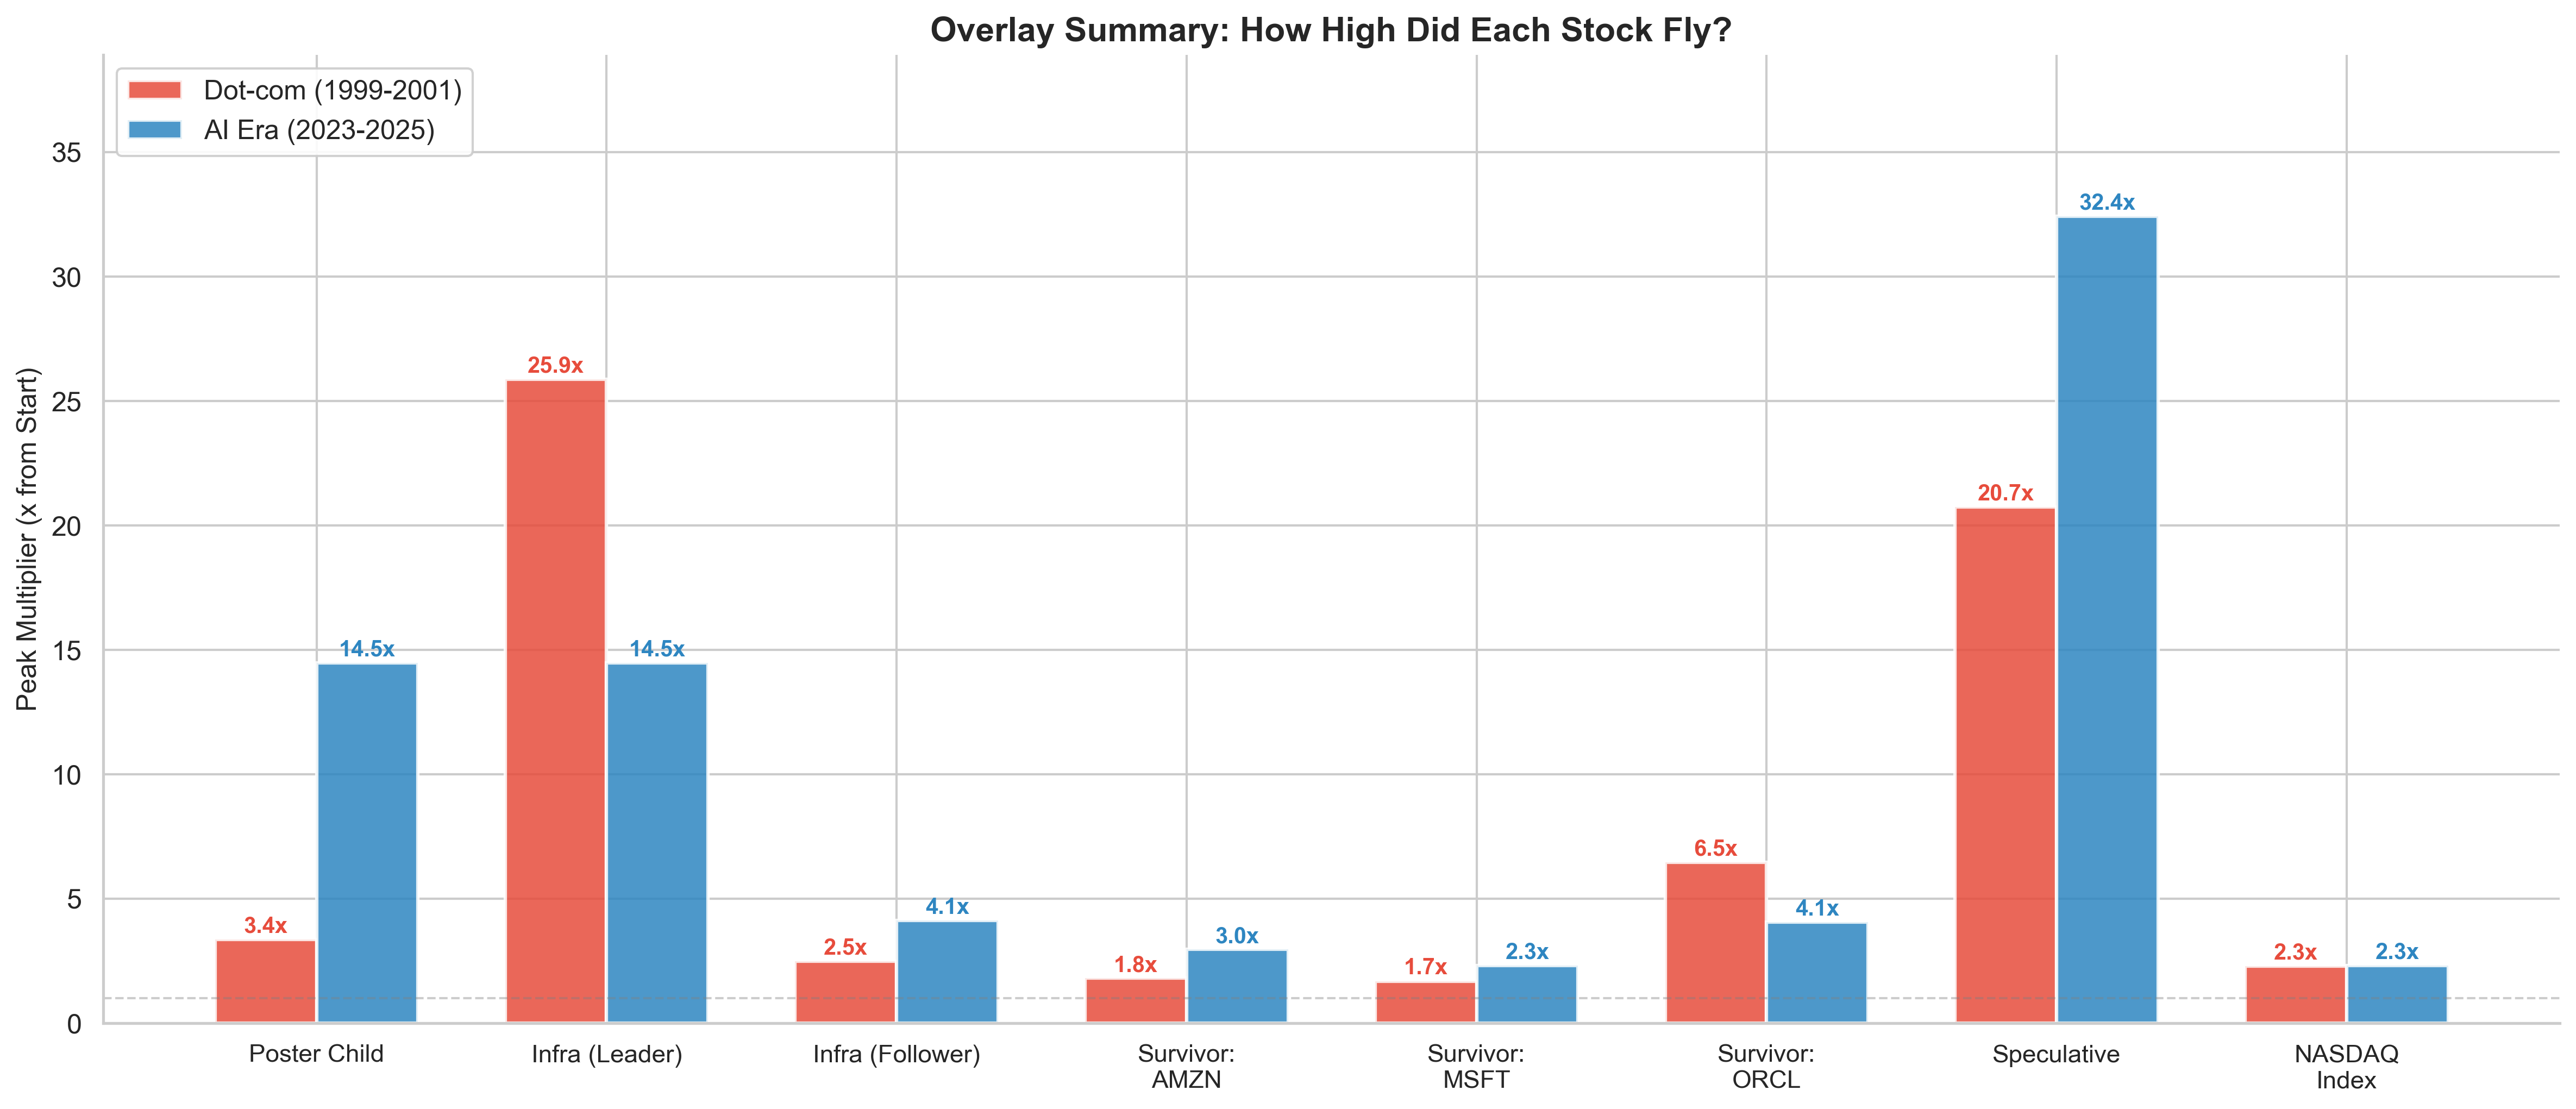

In [15]:
# Overlay Summary: Peak Multiplier Comparison
categories = [
    'Poster Child',
    'Infra (Leader)',
    'Infra (Follower)',
    'Survivor:\nAMZN',
    'Survivor:\nMSFT',
    'Survivor:\nORCL',
    'Speculative',
    'NASDAQ\nIndex'
]

dc_tickers_bar = ['CSCO', 'QCOM', 'INTC', 'AMZN', 'MSFT', 'ORCL', 'MSTR', '^IXIC']
ai_tickers_bar = ['NVDA', 'NVDA', 'AMD', 'AMZN', 'MSFT', 'ORCL', 'PLTR', '^IXIC']

dc_peaks_bar = [normalize(dc_df[t]).max() / 100 for t in dc_tickers_bar]
ai_peaks_bar = [normalize(ai_df[t]).max() / 100 for t in ai_tickers_bar]

import numpy as np
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))

bars_dc = ax.bar(x - width/2, dc_peaks_bar, width, label='Dot-com (1999-2001)',
                 color=C_DOTCOM, alpha=0.85, edgecolor='white', linewidth=1.5)
bars_ai = ax.bar(x + width/2, ai_peaks_bar, width, label='AI Era (2023-2025)',
                 color=C_AI, alpha=0.85, edgecolor='white', linewidth=1.5)

for bar in bars_dc:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}x', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=C_DOTCOM)

for bar in bars_ai:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}x', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=C_AI)

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.set_ylabel('Peak Multiplier (x from Start)', fontsize=12)
ax.set_title('Overlay Summary: How High Did Each Stock Fly?', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(loc='upper left', framealpha=0.9, fontsize=12)
ax.set_ylim(0, max(max(dc_peaks_bar), max(ai_peaks_bar)) * 1.2)

plt.tight_layout()
plt.savefig('figure7.png')
plt.show()

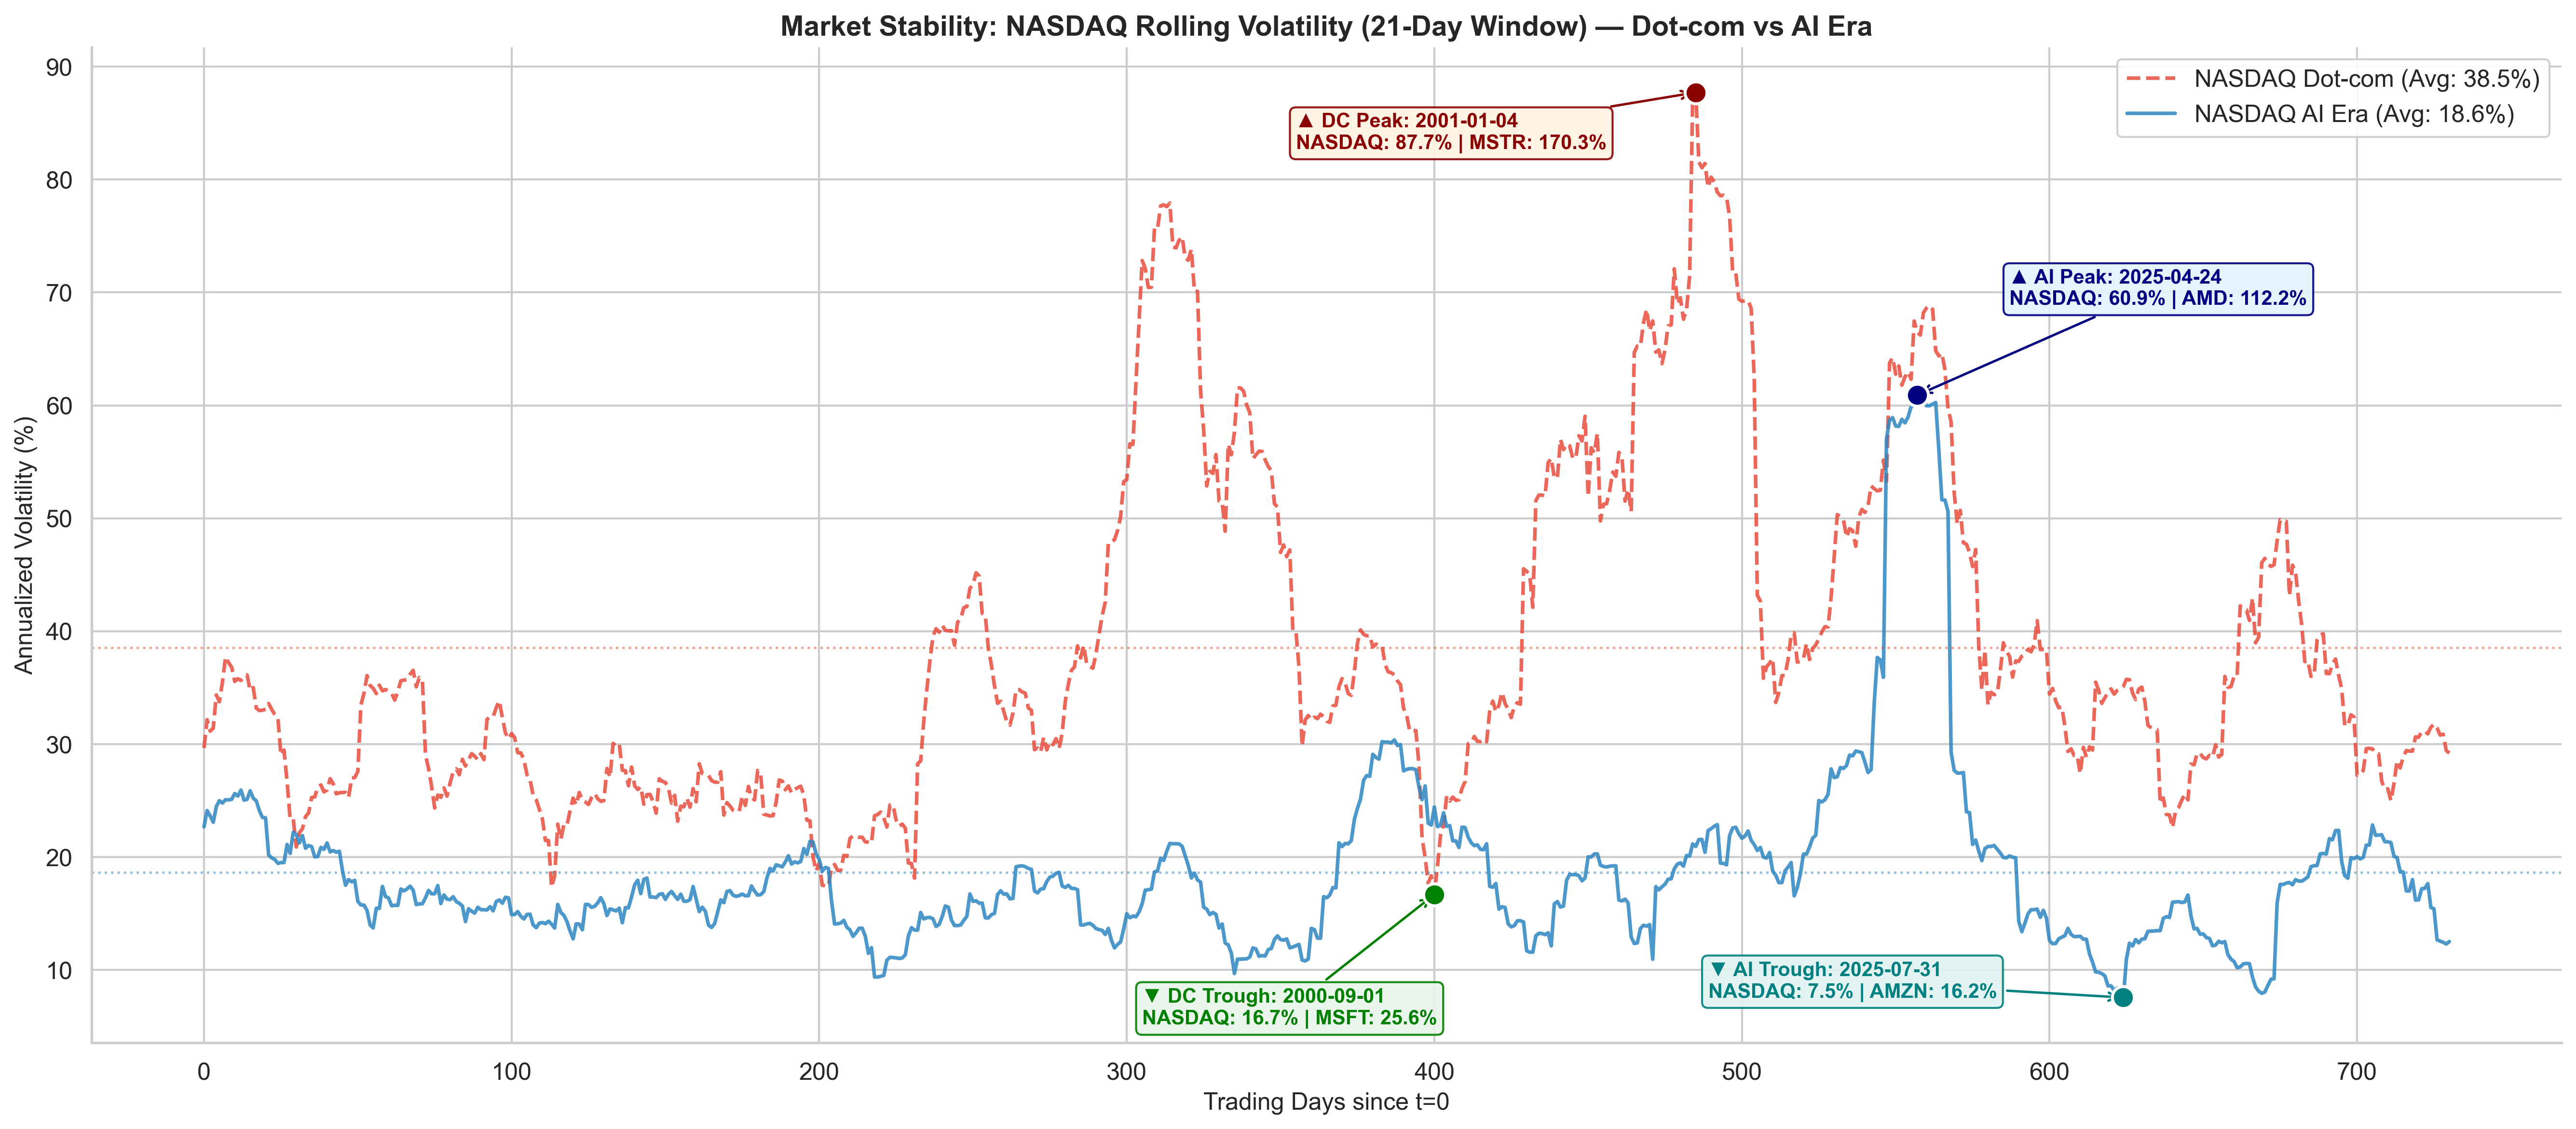

In [16]:
# Market Stability: NASDAQ Rolling Volatility with Spike Analysis
import numpy as np

window = 21  # ~1 month of trading days

dc_nasdaq_ret = dc_df['^IXIC'].pct_change()
ai_nasdaq_ret = ai_df['^IXIC'].pct_change()

dc_vol = dc_nasdaq_ret.rolling(window).std() * np.sqrt(252) * 100
ai_vol = ai_nasdaq_ret.rolling(window).std() * np.sqrt(252) * 100

min_len_vol = min(len(dc_vol.dropna()), len(ai_vol.dropna()))

# Keep date index for spike lookup
dc_vol_clean = dc_vol.dropna().iloc[:min_len_vol]
ai_vol_clean = ai_vol.dropna().iloc[:min_len_vol]

dc_vol_aligned = dc_vol_clean.values
ai_vol_aligned = ai_vol_clean.values
trading_days_vol = range(min_len_vol)

dc_avg_vol = np.mean(dc_vol_aligned)
ai_avg_vol = np.mean(ai_vol_aligned)

# --- Find peak & trough of NASDAQ volatility ---
dc_peak_idx = np.argmax(dc_vol_aligned)
dc_trough_idx = np.argmin(dc_vol_aligned)
dc_peak_date = dc_vol_clean.index[dc_peak_idx]
dc_trough_date = dc_vol_clean.index[dc_trough_idx]
dc_peak_val = dc_vol_aligned[dc_peak_idx]
dc_trough_val = dc_vol_aligned[dc_trough_idx]

ai_peak_idx = np.argmax(ai_vol_aligned)
ai_trough_idx = np.argmin(ai_vol_aligned)
ai_peak_date = ai_vol_clean.index[ai_peak_idx]
ai_trough_date = ai_vol_clean.index[ai_trough_idx]
ai_peak_val = ai_vol_aligned[ai_peak_idx]
ai_trough_val = ai_vol_aligned[ai_trough_idx]

# Find which stock had highest/lowest vol at peak/trough
dc_stocks = [c for c in dc_df.columns if c != '^IXIC']
ai_stocks = [c for c in ai_df.columns if c != '^IXIC']

def find_top_stock_at_date(df, stocks, target_date, window=21):
    vol_at_date = {}
    for s in stocks:
        ret = df[s].pct_change()
        vol = ret.rolling(window).std() * np.sqrt(252) * 100
        if target_date in vol.index and not np.isnan(vol.loc[target_date]):
            vol_at_date[s] = vol.loc[target_date]
    if vol_at_date:
        top = max(vol_at_date, key=vol_at_date.get)
        return top, vol_at_date[top]
    return None, None

def find_bottom_stock_at_date(df, stocks, target_date, window=21):
    vol_at_date = {}
    for s in stocks:
        ret = df[s].pct_change()
        vol = ret.rolling(window).std() * np.sqrt(252) * 100
        if target_date in vol.index and not np.isnan(vol.loc[target_date]):
            vol_at_date[s] = vol.loc[target_date]
    if vol_at_date:
        bottom = min(vol_at_date, key=vol_at_date.get)
        return bottom, vol_at_date[bottom]
    return None, None

dc_peak_stock, dc_peak_stock_vol = find_top_stock_at_date(dc_df, dc_stocks, dc_peak_date)
dc_trough_stock, dc_trough_stock_vol = find_bottom_stock_at_date(dc_df, dc_stocks, dc_trough_date)
ai_peak_stock, ai_peak_stock_vol = find_top_stock_at_date(ai_df, ai_stocks, ai_peak_date)
ai_trough_stock, ai_trough_stock_vol = find_bottom_stock_at_date(ai_df, ai_stocks, ai_trough_date)

# Combined Overlay with Spike Annotations
fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(trading_days_vol, dc_vol_aligned, color=C_DOTCOM, linewidth=1.8,
        linestyle='--', alpha=0.85,
        label=f'NASDAQ Dot-com (Avg: {dc_avg_vol:.1f}%)')

ax.plot(trading_days_vol, ai_vol_aligned, color=C_AI, linewidth=1.8,
        alpha=0.85,
        label=f'NASDAQ AI Era (Avg: {ai_avg_vol:.1f}%)')

ax.axhline(y=dc_avg_vol, color=C_DOTCOM, linestyle=':', alpha=0.5, linewidth=1.2)
ax.axhline(y=ai_avg_vol, color=C_AI, linestyle=':', alpha=0.5, linewidth=1.2)

# Dot-com Peak
ax.scatter([dc_peak_idx], [dc_peak_val], color='darkred', s=120, zorder=5, edgecolors='white', linewidths=1.5)
ax.annotate(
    f'\u25b2 DC Peak: {dc_peak_date.strftime("%Y-%m-%d")}\n'
    f'NASDAQ: {dc_peak_val:.1f}% | {dc_peak_stock}: {dc_peak_stock_vol:.1f}%',
    xy=(dc_peak_idx, dc_peak_val),
    xytext=(dc_peak_idx - 130, dc_peak_val - 5),
    fontsize=10, fontweight='bold', color='darkred',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='darkred', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2)
)

# Dot-com Trough
ax.scatter([dc_trough_idx], [dc_trough_val], color='green', s=120, zorder=5, edgecolors='white', linewidths=1.5)
ax.annotate(
    f'\u25bc DC Trough: {dc_trough_date.strftime("%Y-%m-%d")}\n'
    f'NASDAQ: {dc_trough_val:.1f}% | {dc_trough_stock}: {dc_trough_stock_vol:.1f}%',
    xy=(dc_trough_idx, dc_trough_val),
    xytext=(dc_trough_idx - 95, dc_trough_val - 11.5),
    fontsize=10, fontweight='bold', color='green',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor='green', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='green', lw=1.2)
)

# AI Peak 
ax.scatter([ai_peak_idx], [ai_peak_val], color='navy', s=120, zorder=5, edgecolors='white', linewidths=1.5)
ax.annotate(
    f'\u25b2 AI Peak: {ai_peak_date.strftime("%Y-%m-%d")}\n'
    f'NASDAQ: {ai_peak_val:.1f}% | {ai_peak_stock}: {ai_peak_stock_vol:.1f}%',
    xy=(ai_peak_idx, ai_peak_val),
    xytext=(ai_peak_idx + 30, ai_peak_val + 8),
    fontsize=10, fontweight='bold', color='navy',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', edgecolor='navy', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='navy', lw=1.2)
)

# AI Trough 
ax.scatter([ai_trough_idx], [ai_trough_val], color='teal', s=120, zorder=5, edgecolors='white', linewidths=1.5)
ax.annotate(
    f'\u25bc AI Trough: {ai_trough_date.strftime("%Y-%m-%d")}\n'
    f'NASDAQ: {ai_trough_val:.1f}% | {ai_trough_stock}: {ai_trough_stock_vol:.1f}%',
    xy=(ai_trough_idx, ai_trough_val),
    xytext=(ai_trough_idx - 135, ai_trough_val + 0),
    fontsize=10, fontweight='bold', color='teal',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#E0F2F1', edgecolor='teal', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='teal', lw=1.2)
)

ax.set_xlabel('Trading Days since t=0', fontsize=12)
ax.set_ylabel('Annualized Volatility (%)', fontsize=12)
ax.set_title('Market Stability: NASDAQ Rolling Volatility (21-Day Window) \u2014 Dot-com vs AI Era',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9, fontsize=12)

plt.tight_layout()
plt.savefig('figure8.png')
plt.show()

## Final Verdict 

### Similarities
1. **Narrative-driven Rally**: Both eras were fueled by powerful narratives ("The Internet changes everything" / "AI changes everything")
2. **Infrastructure stocks lead**: Infrastructure builders (CSCO, NVDA) rallied first and hardest
3. **Speculation rises**: Speculative stocks (MSTR, PLTR) exhibited extreme volatility — a hallmark of Retail Frenzy

### Differences
1. **Concentration risk**: The AI rally is far more concentrated in NVDA compared to the Dot-com era
2. **Profitability**: NVDA has real, substantial earnings (unlike CSCO's sky-high P/E at peak)
3. **Speed**: NVDA's ascent may be steeper than CSCO's over the same number of trading days

